# NNM delta-mass (h) variation
This notebook computes and plots the first three entries of `h` (delta masses) from the NNM flavour model while varying `r` for several `N` values, and varying `N` for several `r` values.
It uses the project code in this repository (loads `Newtrinos`).

In [1]:
# Activate minimal imports
using Newtrinos
using CairoMakie
using Colors
using LinearAlgebra


In [65]:
# Build the oscillation object for NNM and extract the matrices function
osc_cfg = Newtrinos.osc.OscillationConfig(flavour = Newtrinos.osc.NND(three_flavour=Newtrinos.osc.ThreeFlavour(ordering=:NO)))
osc = Newtrinos.osc.configure(osc_cfg)
matrices_fun = osc.matrices
base_params = osc.params
# show m0 to verify params available
@show base_params.m₀

base_params.m₀ = 0.01


0.01

In [ ]:
# Part 1: vary r for several fixed N values
Ns = [10, 20, 100]
rs = 10 .^ range(-8, 0, length=80)  
rr=1 ./ (rs)# 1/r
savedir = "/home/sofialon/Newtrinos.jl/plots_NNM_s"
isdir(savedir) || mkpath(savedir)
results_by_N = Dict{Int, Matrix{Float64}}()

for N in Ns
    hvals = zeros(length(rs), 3)
    for (i, r) in enumerate(rs)
        params = merge(base_params, (N = float(N), r = r))
        
        # call matrices_fun and extract h robustly (different variants return different tuples)
        res = matrices_fun(params)
        if length(res) >= 2
            h = res[2]
        else
            error("matrices function did not return h for N=$N r=$r")
        end
        # store first three entries (convert to Float64)
       
        hvals[i, 1] = Float64(h[1])
        hvals[i, 2] = Float64(h[2])
        hvals[i, 3] = Float64(h[3])
    end
    results_by_N[N] = hvals
end


┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/scenes.jl:238


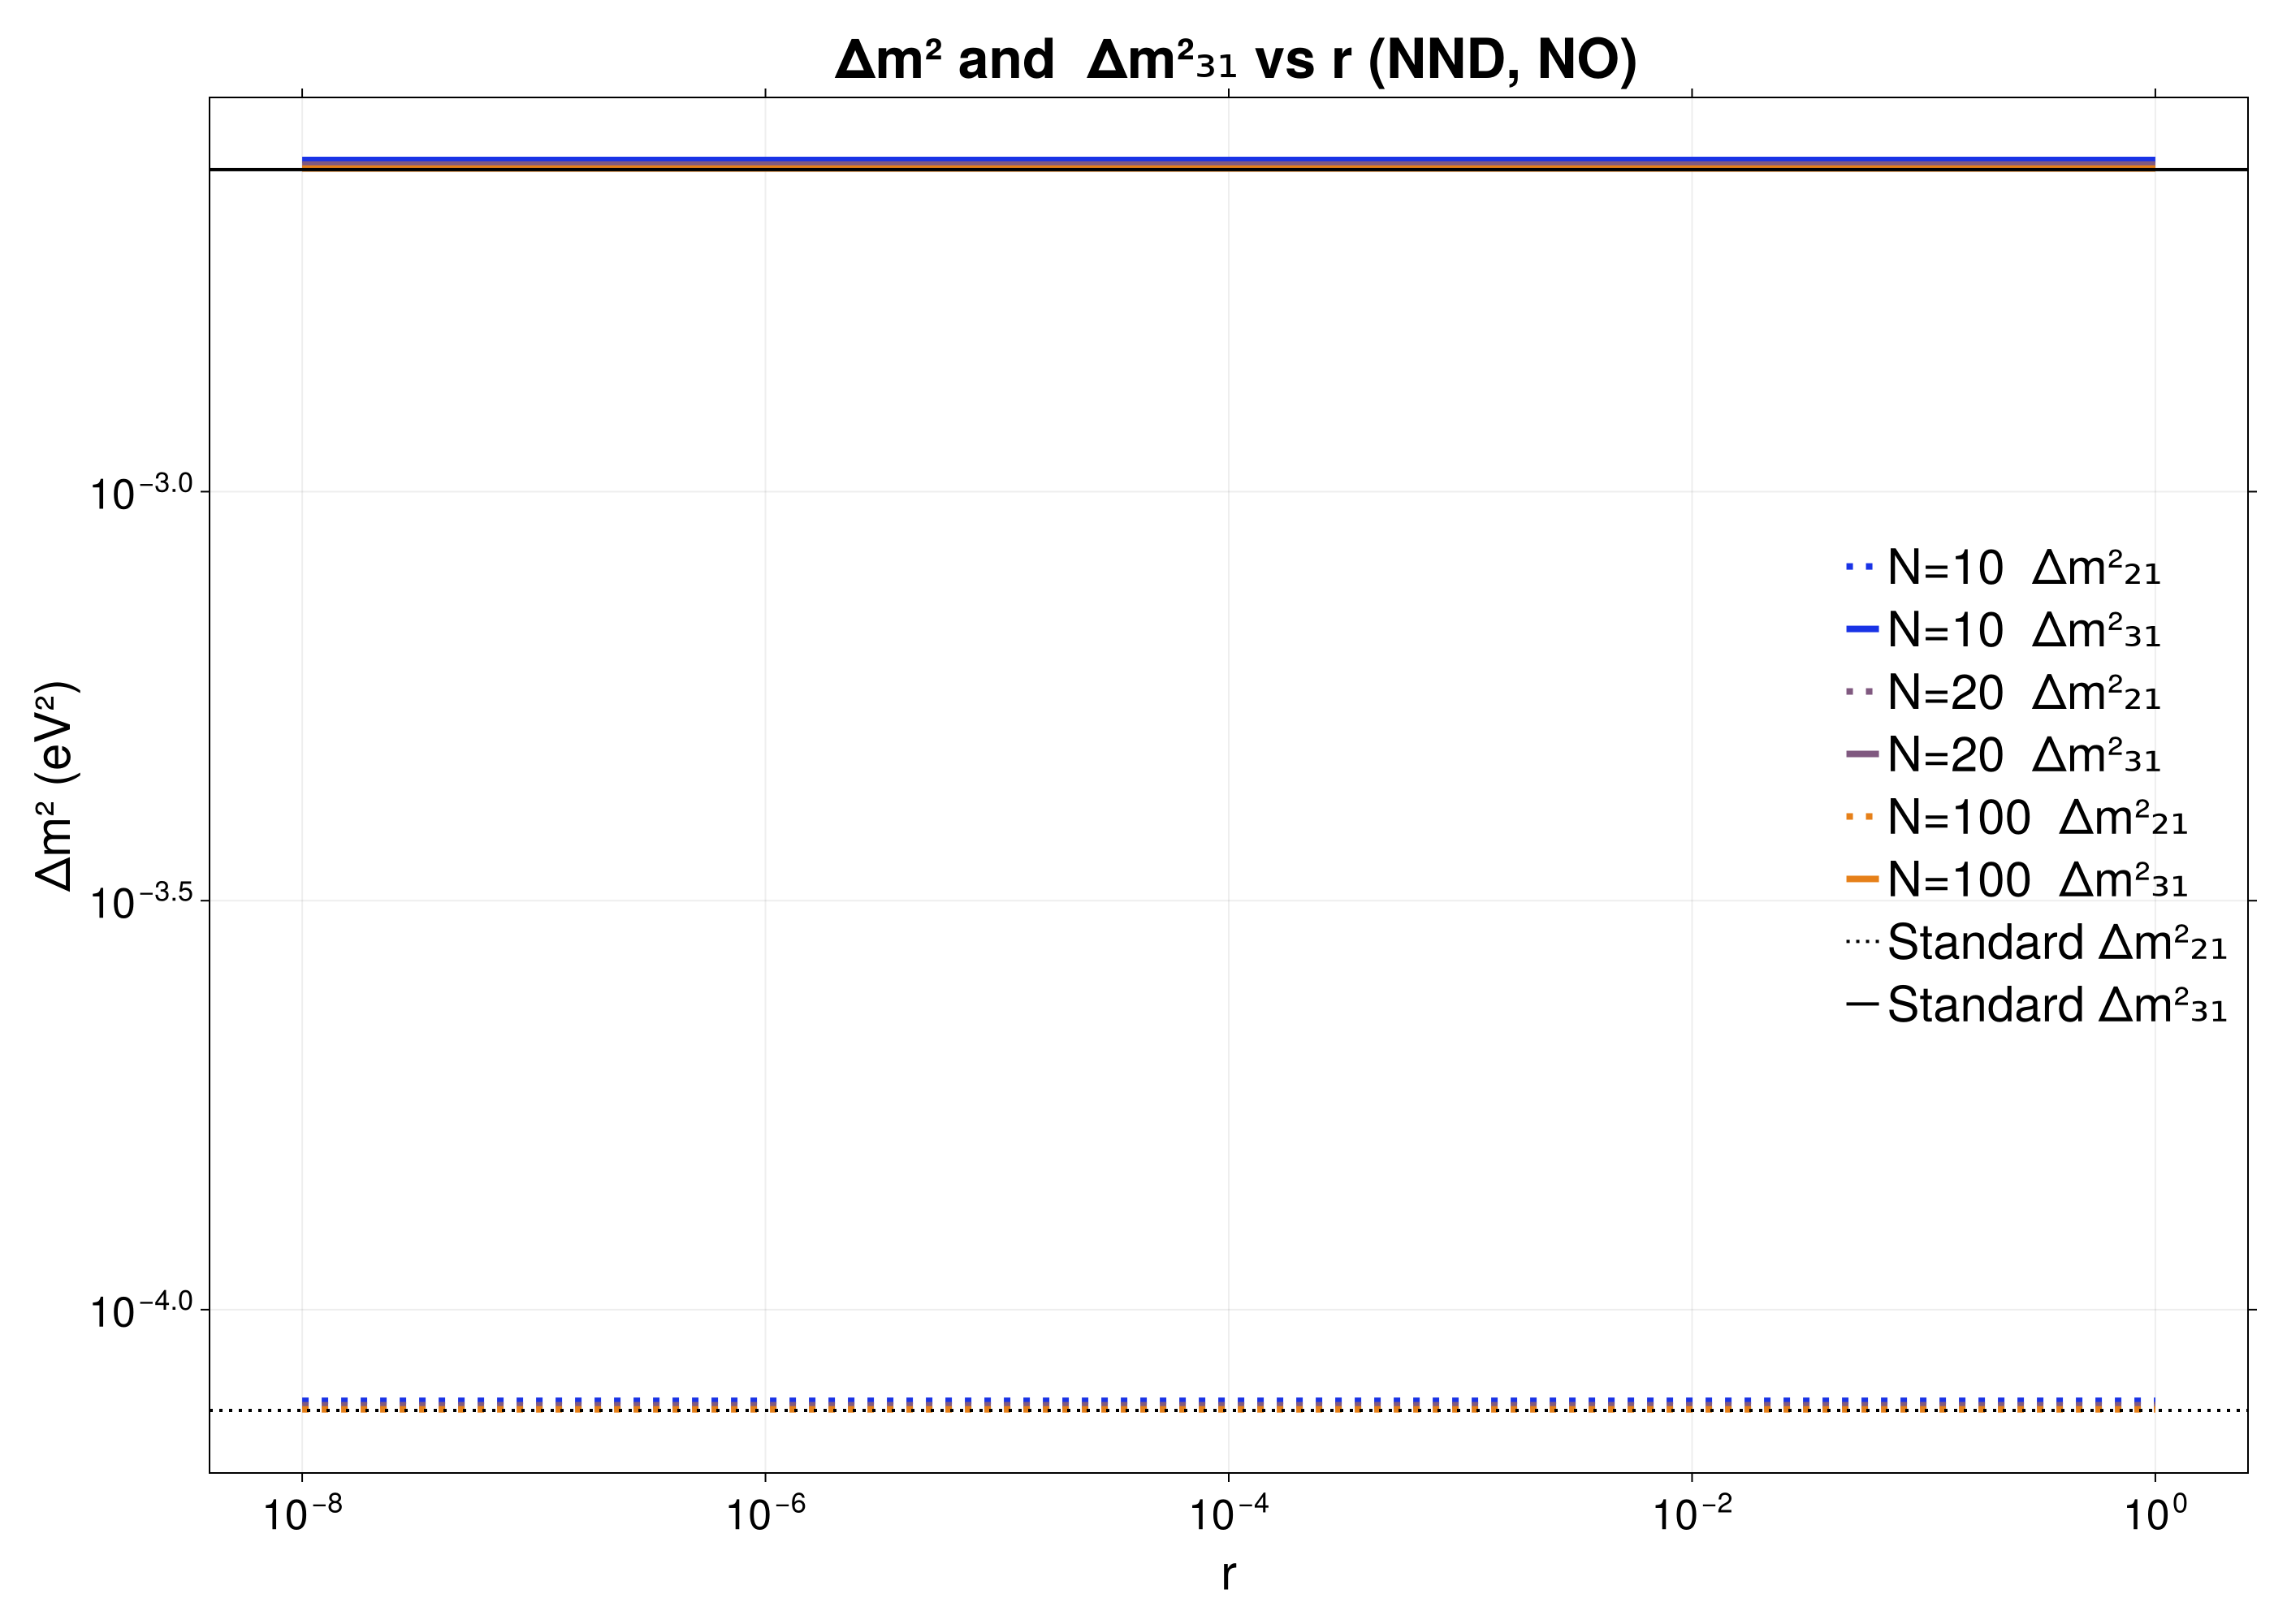

In [ ]:
using CairoMakie
using Colors

fig = Figure(resolution = (1400, 1000), font = "DejaVu Sans")

ax = Axis(
    fig[1, 1],
    xlabel = "r",
    ylabel = "Δm² (eV²)",
    title = " Δm² and  Δm²₃₁ vs r (NNM, NO)",
    xscale = log10,
    yscale = log10,
    xlabelsize=30,
    ylabelsize=30,
    titlesize=34,
    xticklabelsize=26,
    yticklabelsize=26,
    xgridvisible=true,
    ygridvisible=true,
    xgridcolor=:gray90,
    ygridcolor=:gray90,
    xticksmirrored=true,
    yticksmirrored=true
)

# ---- Create a CLEAR gradient (blue → green → orange) ----
start_color = RGB(0.1, 0.2, 0.9)     # deep blue
end_color   = RGB(0.9, 0.5, 0.1)     # strong orange
palette = collect(range(start_color, stop=end_color, length=length(Ns)))

for (idx, N) in enumerate(Ns)
    hvals = results_by_N[N]
    color = palette[idx]

    # All solid, thick lines
    #lines!(ax, rs, hvals[:, 1], color = color, linewidth = 4,
         # label = "N=$N  Δm²₁")

    lines!(ax, rs, hvals[:, 2], color = color, linewidth = 4,linestyle=:dot,
           label = "N=$N  Δm²₂₁")

    lines!(ax, rs, hvals[:, 3], color = color, linewidth = 4,
           label = "N=$N  Δm²₃₁")

          
end
 hlines!(ax, base_params.Δm²₂₁, color =:black, linewidth = 2,linestyle=:dot,
           label = "Standard Δm²₂₁")    
        
        
    hlines!(ax, base_params.Δm²₃₁, color =:black, linewidth = 2,linestyle=:solid,
        label = "Standard Δm²₃₁")   

# Clean subtle solid grid
ax.xgridvisible = true
ax.ygridvisible = true
ax.xgridstyle = :solid
ax.ygridstyle = :solid
ax.xgridcolor = RGBAf(0,0,0,0.07)
ax.ygridcolor = RGBAf(0,0,0,0.07)

axislegend(ax;
    position = :rc,
    labelsize = 30,
    framevisible = false
)

#save(joinpath(savedir, "h_vs_r_by_N_firstNNM.png"), fig)
display("image/png",fig)

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/scenes.jl:238


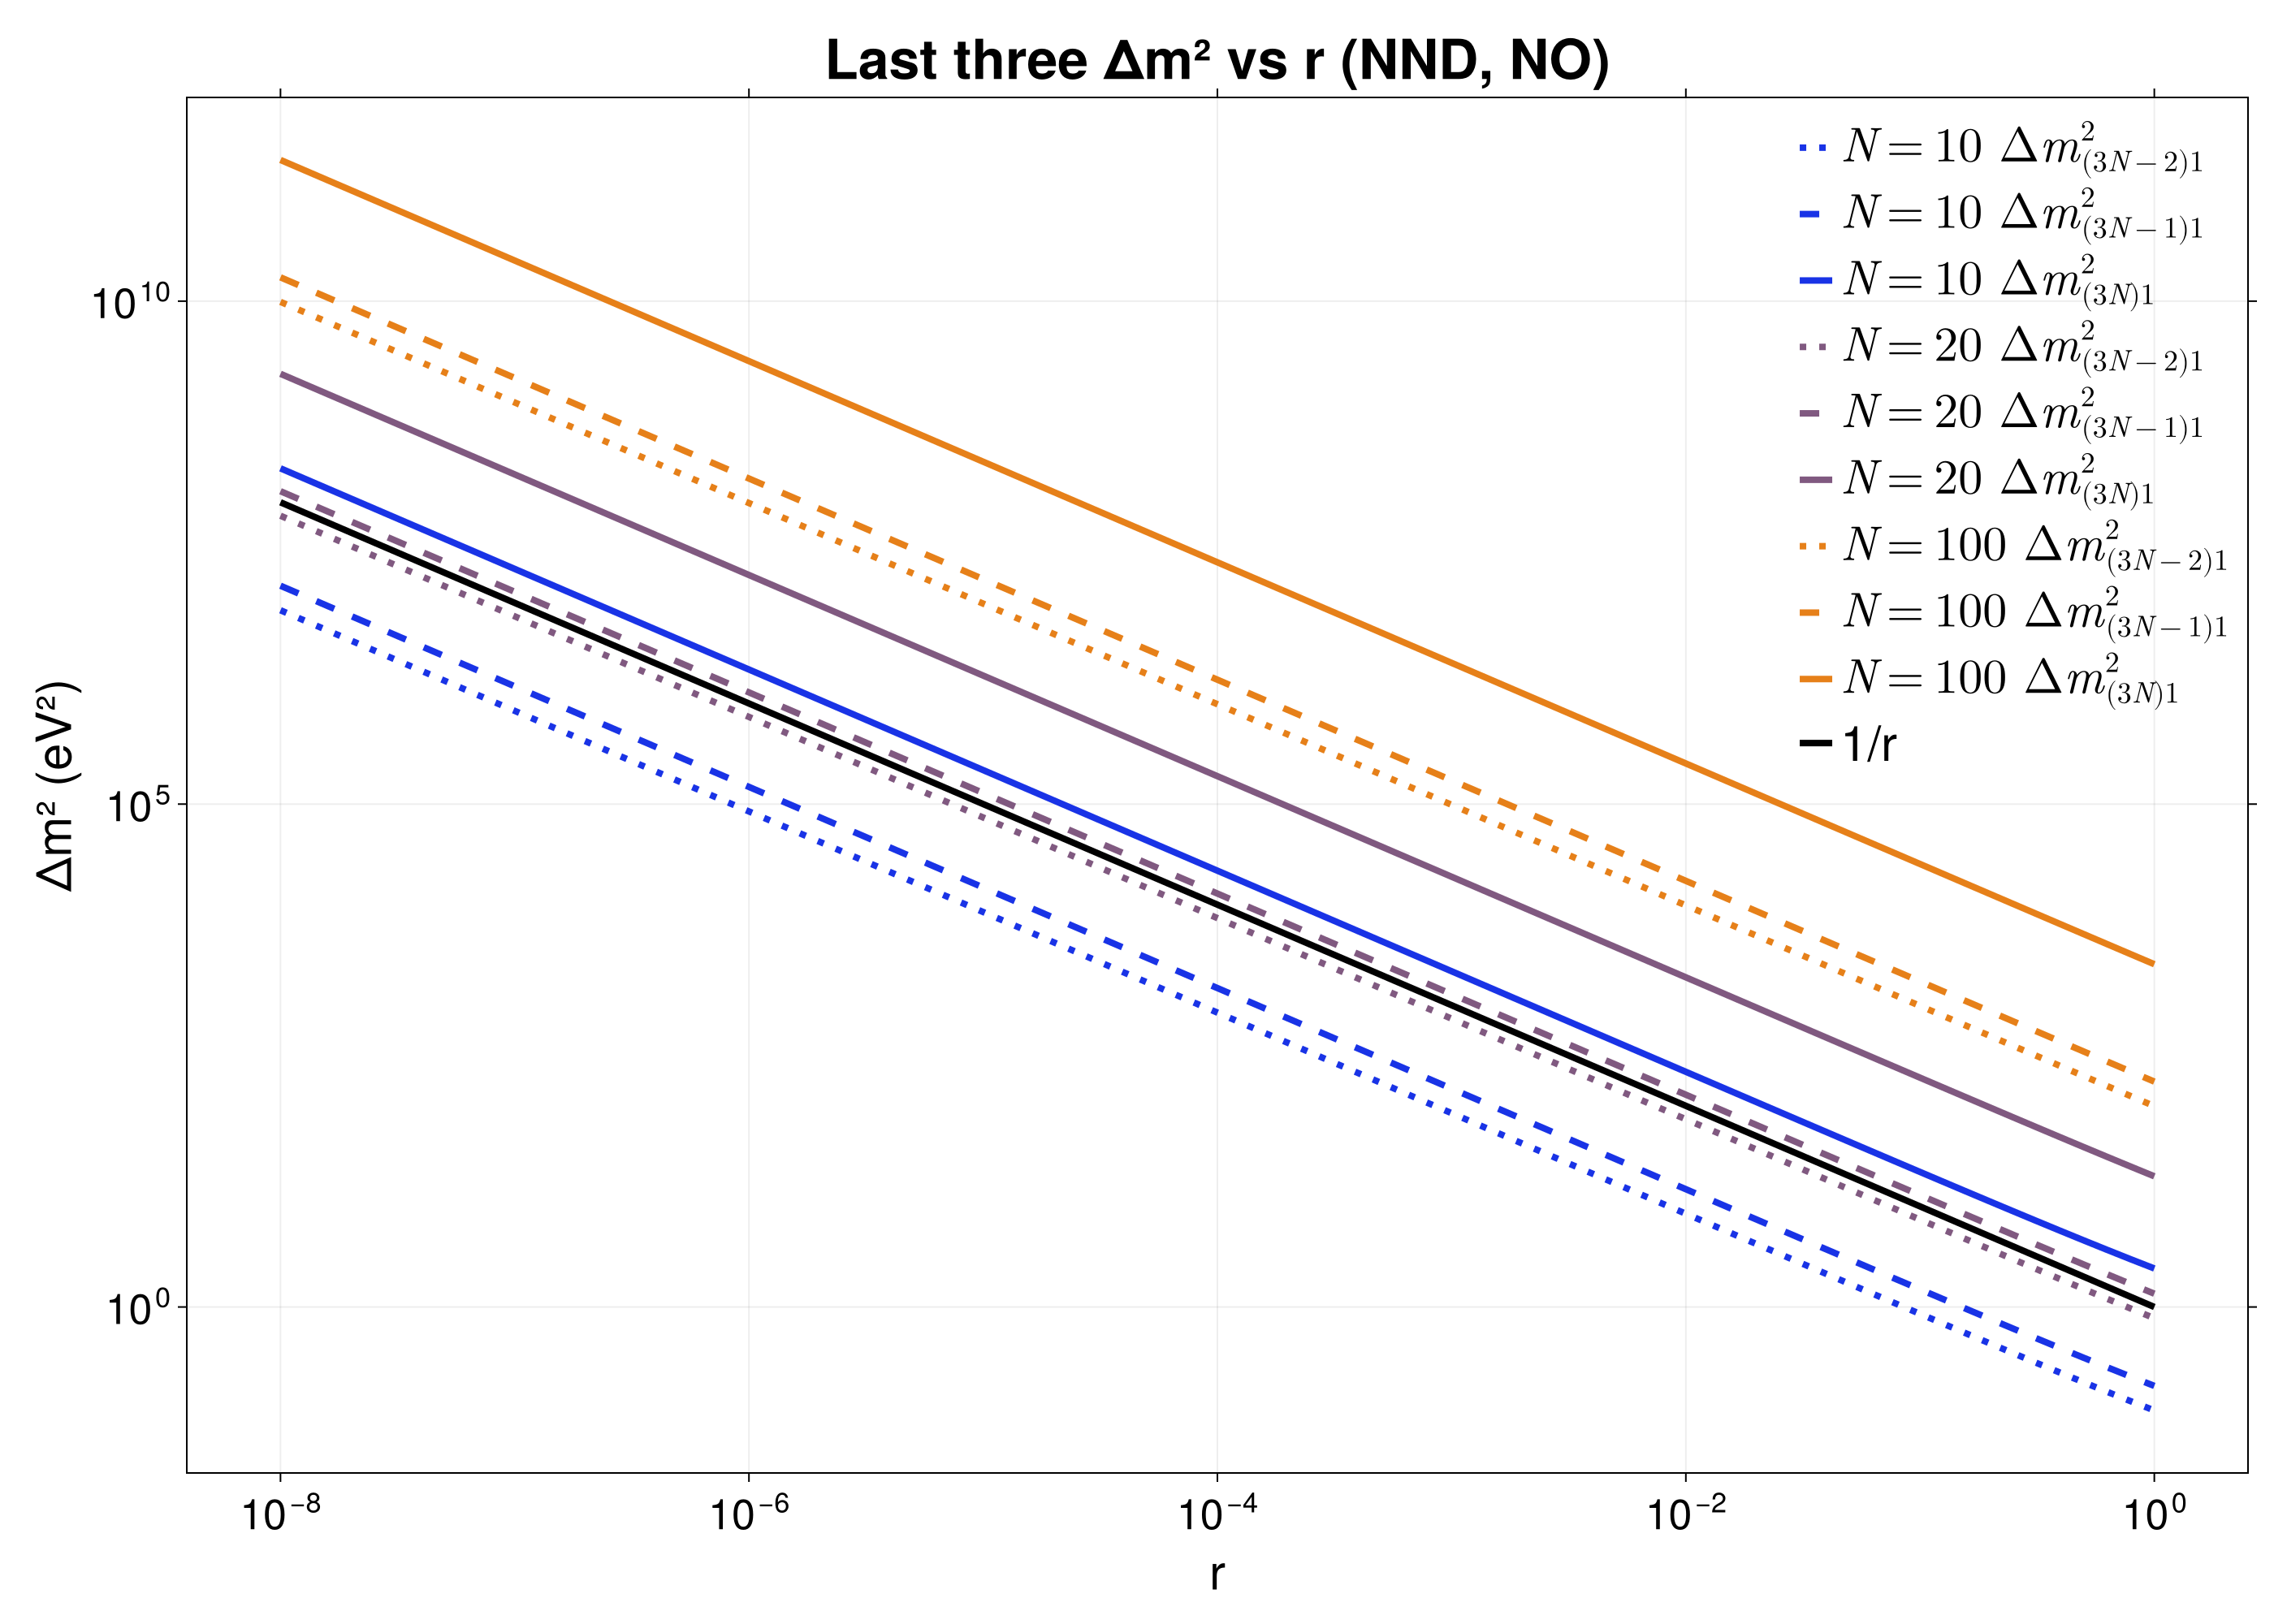

CairoMakie.Screen{IMAGE}


In [ ]:
using CairoMakie
using Colors
using LaTeXStrings

fig = Figure(resolution = (1400, 1000), font = "DejaVu Sans")

ax = Axis(
    fig[1, 1],
    xlabel = "r",
    ylabel = "Δm² (eV²)",
    title = "Last three Δm² vs r (NNM, NO)",
    xscale = log10,
    yscale = log10,
    xlabelsize=30,
    ylabelsize=30,
    titlesize=34,
    xticklabelsize=26,
    yticklabelsize=26,
    xgridvisible=true,
    ygridvisible=true,
    xgridcolor=:gray90,
    ygridcolor=:gray90,
    xticksmirrored=true,
    yticksmirrored=true
)

# ---- Clear blue → orange gradient ----
start_color = RGB(0.1, 0.2, 0.9)     # deep blue
end_color   = RGB(0.9, 0.5, 0.1)     # strong orange
palette = collect(range(start_color, stop=end_color, length=length(Ns)))

for (idx, N) in enumerate(Ns)
    hvals = results_by_N[N]
    color = palette[idx]
       lines!(
        ax,
        rs,
        hvals[:, 1],
        color = color,
        linewidth = 4,
        linestyle=:dot,
        label = L"N=%$N\ \Delta m^2_{(3N-2)1}"  
    )
    # Δm²_{N-1,1}
    lines!(
        ax,
        rs,
        hvals[:, 2],
        color = color,
        linewidth = 4,
        linestyle=:dash,
        label = L"N=%$N\ \Delta m^2_{(3N-1)1}"
    
    )

    # Δm²_{N1}
    lines!(
        ax,
        rs,
        hvals[:, 3],
        color = color,
        linewidth = 4,
        label = L"N=%$N\ \Delta m^2_{(3N)1}"

    )

end
    lines!(
        ax,
        rs,
        rr,
        color = :black,
        linewidth = 4,
        label = "1/r "

    )

# ---- Clean subtle solid grid ----
ax.xgridvisible = true
ax.ygridvisible = true
ax.xgridstyle = :solid
ax.ygridstyle = :solid
ax.xgridcolor = RGBAf(0,0,0,0.07)
ax.ygridcolor = RGBAf(0,0,0,0.07)

axislegend(
    ax,
    position = :rt,
    labelsize=30,
    framevisible = false
)

save(joinpath(savedir, "h_vs_r_by_N_high_guideNNM.png"), fig)

display(fig)

In [ ]:
# Part 2: vary N for several fixed r values
rs = [1e-6, 1e-4, 1e-2, 1]
Ns = LinRange(10, 500,100)   
NN= (Ns).^3

savedir = "/home/sofialon/Newtrinos.jl/plots_NNM_s"
isdir(savedir) || mkpath(savedir)

results_by_r = Dict{Float64, Matrix{Float64}}()  # r => (length(Ns) x 3) matrix for h1,h2,h3

for r in rs
    hvals = zeros(length(Ns), 3)

    for (i, N) in enumerate(Ns)
        params = merge(base_params, (N = float(N), r = r))

        # call matrices_fun and extract h robustly
        res = matrices_fun(params)
        if length(res) >= 2
            h = res[2]
        else
            error("matrices function did not return h for r=$r N=$N")
        end

        # store first three entries
        hvals[i, 1] = Float64(h[1])
        hvals[i, 2] = Float64(h[2])
        hvals[i, 3] = Float64(h[3])
    end

    results_by_r[r] = hvals
end

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/scenes.jl:238


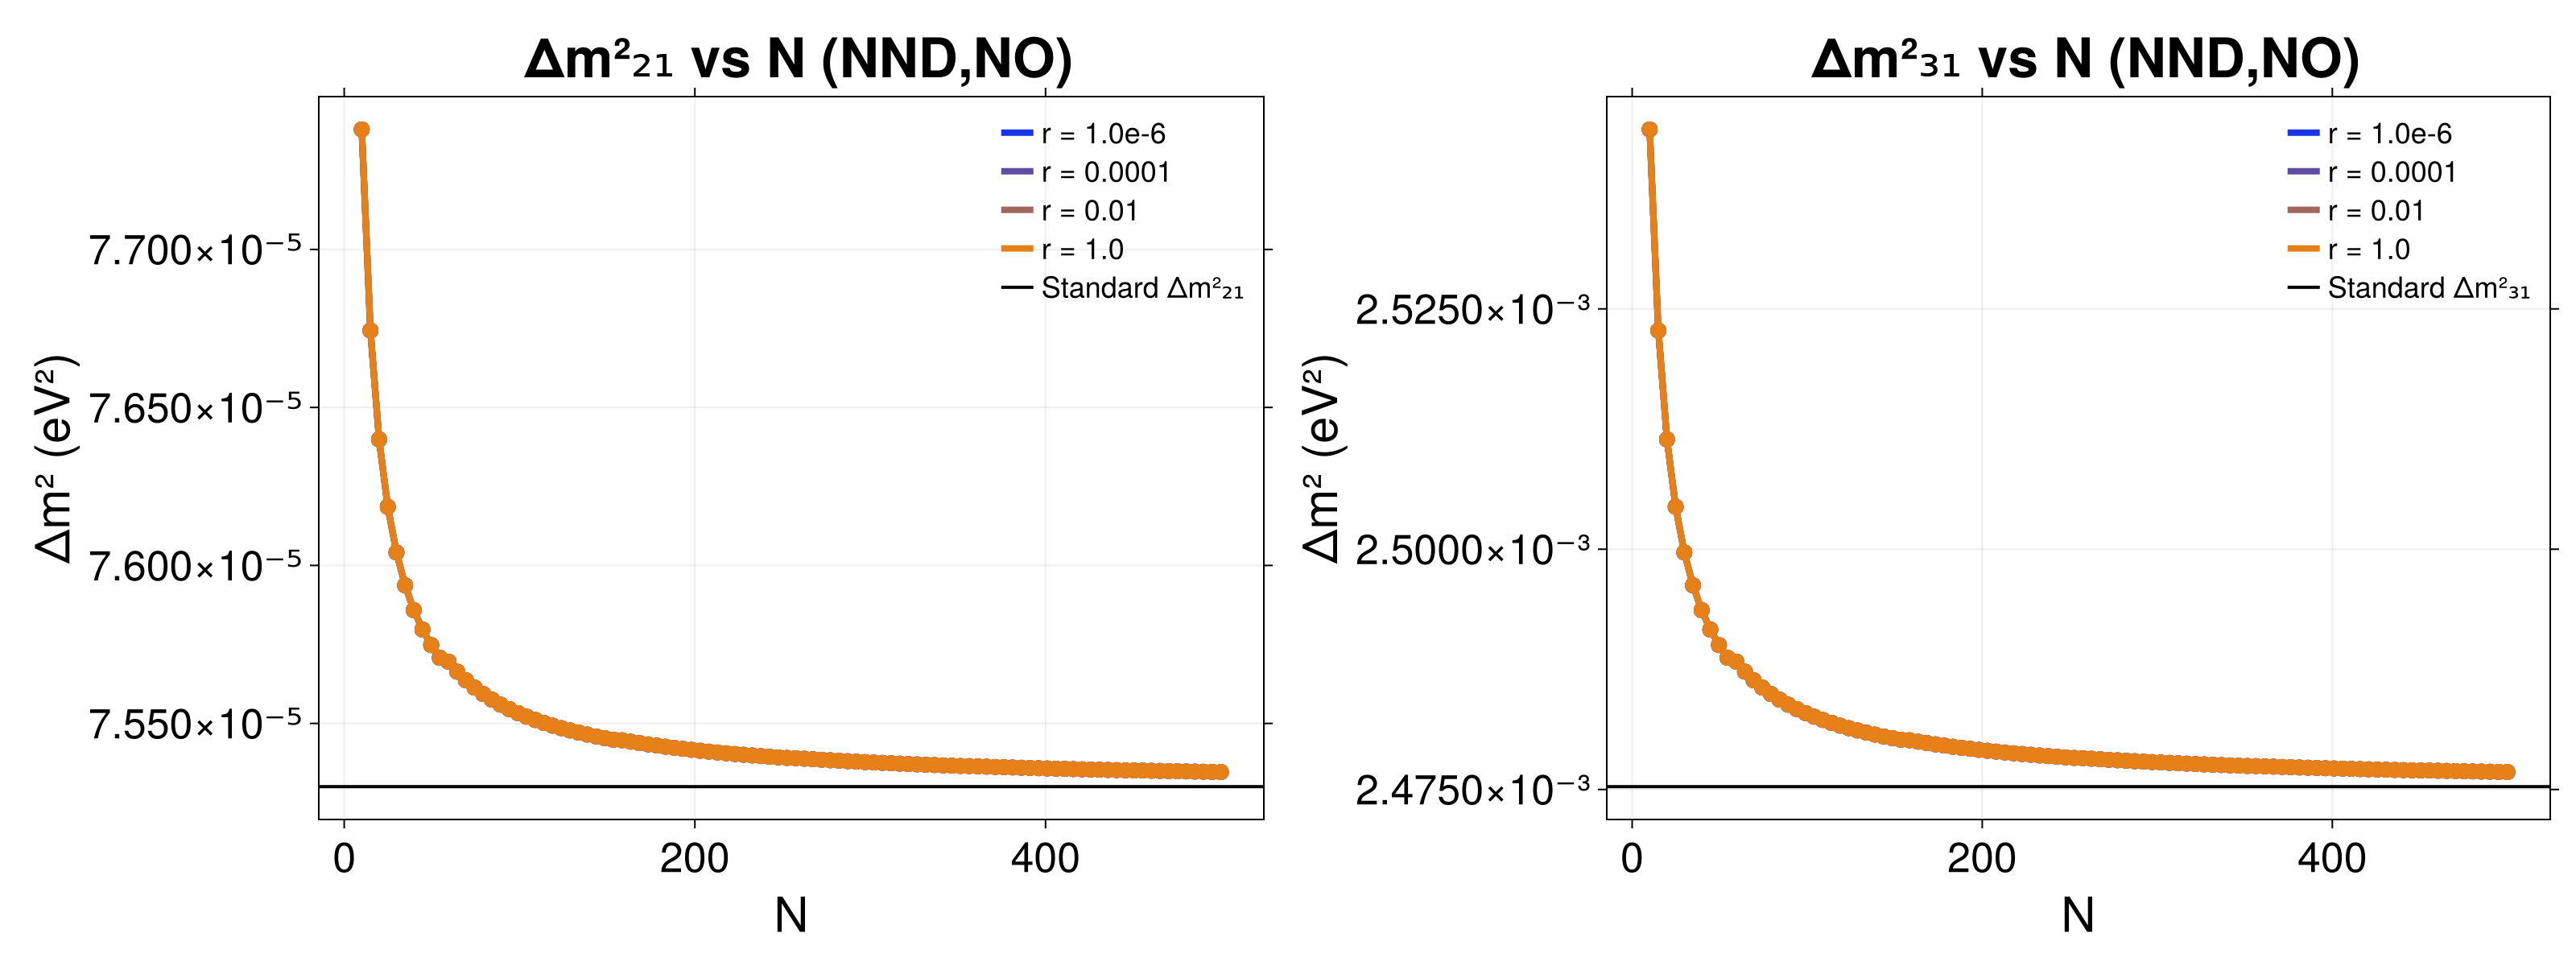

CairoMakie.Screen{IMAGE}


In [ ]:
using CairoMakie
using Colors

fig2 = Figure(resolution = (1600, 600), font = "DejaVu Sans")

# ---- Strong visible gradient for r values ----
start_color = RGB(0.1, 0.2, 0.9)   # deep blue
end_color   = RGB(0.9, 0.5, 0.1)   # strong orange
palette = collect(range(start_color, stop=end_color, length=length(rs)))
delta=[0,base_params.Δm²₂₁, base_params.Δm²₃₁]
stringname=["", "Δm²₂₁", "Δm²₃₁"]

for j in 2:3
    ax = Axis(
       fig2[1, j-1],
        xlabel = "N",
        ylabel = "Δm² (eV²)",
        title = " $(stringname[j]) vs N (NNM,NO)",
       # yscale = log10,
        xlabelsize=30,
        ylabelsize=30,
        titlesize=34,
        xticklabelsize=26,
        yticklabelsize=26,
        xgridvisible=true,
        ygridvisible=true,
        xgridcolor=:gray90,
        ygridcolor=:gray90,
        xticksmirrored=true,
        yticksmirrored=true
    )

    for (ir, r) in enumerate(rs)

        hvals = results_by_r[r]
        color = palette[ir]

        lines!(
            ax,
            Ns,
            hvals[:, j],
            color = color,
            linewidth = 4,
            label = "r = $(r)"
        )

        scatter!(
            ax,
            Ns,
            hvals[:, j],
            color = color,
            marker = :circle,
            markersize = 14
        )
       
    end

    hlines!(ax, delta[j], color =:black, linewidth = 2,linestyle=:solid,
    label = "Standard $(stringname[j])")
        
      

    # subtle grid
    ax.xgridstyle = :solid
    ax.ygridstyle = :solid
    ax.xgridcolor = RGBAf(0,0,0,0.07)
    ax.ygridcolor = RGBAf(0,0,0,0.07)

    axislegend(
        ax,
        position = :rt,
        labelsize = 18,
        framevisible = false
    )
end

save(joinpath(savedir, "h_vs_N_by_rNNM.png"), fig2)
display(fig2)

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/scenes.jl:238


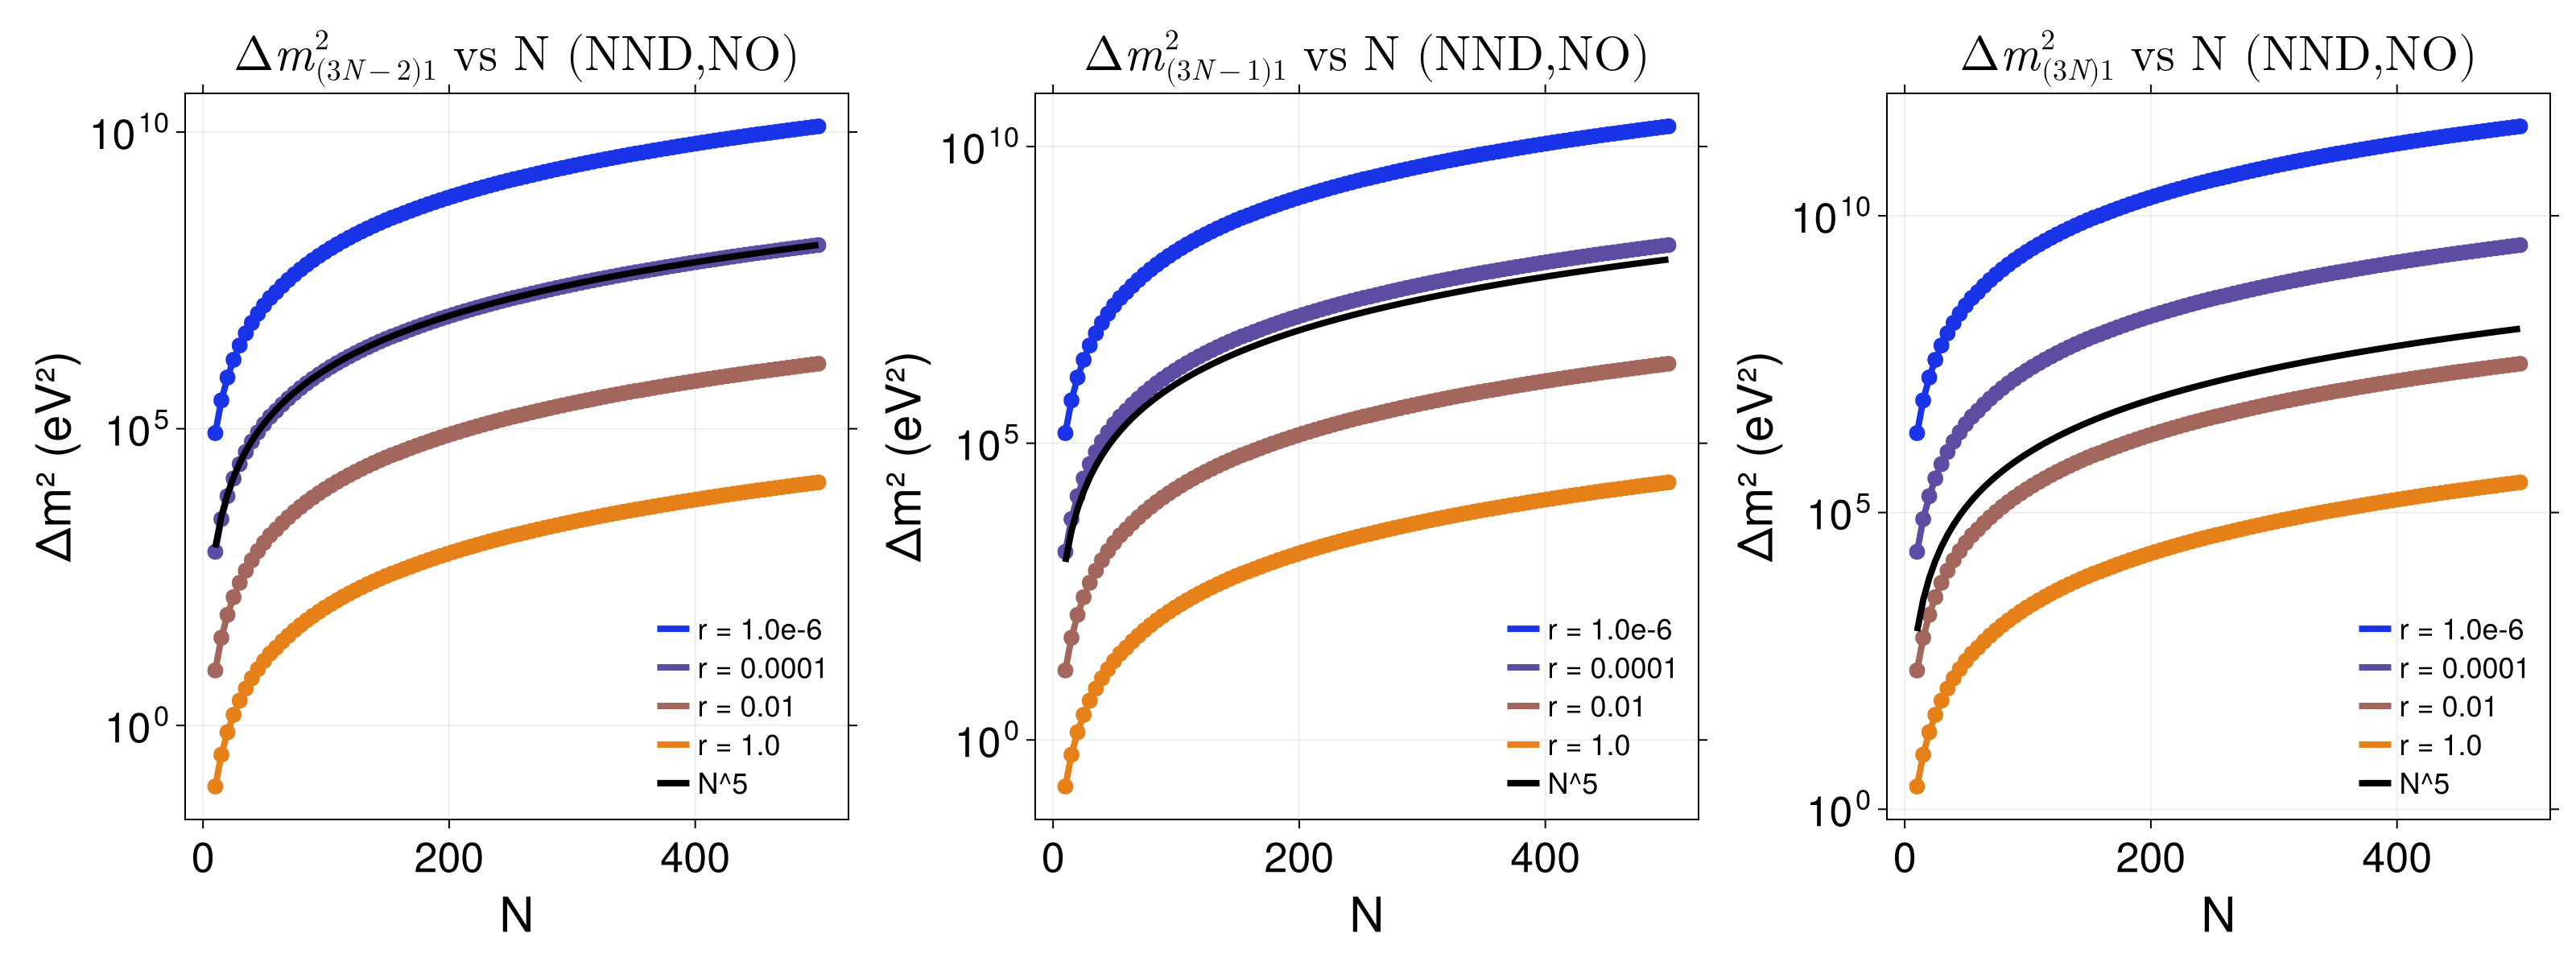

CairoMakie.Screen{IMAGE}


In [ ]:
using CairoMakie
using Colors

fig2 = Figure(resolution = (1600, 600), font = "DejaVu Sans")

# ---- Strong visible gradient for r values ----
start_color = RGB(0.1, 0.2, 0.9)   # deep blue
end_color   = RGB(0.9, 0.5, 0.1)   # strong orange
palette = collect(range(start_color, stop=end_color, length=length(rs)))
delta=[0,base_params.Δm²₂₁, base_params.Δm²₃₁]
stringname=[L"\Delta m^2_{(3N-2)1}", L"\Delta m^2_{(3N-1)1}", L"\Delta m^2_{(3N)1}"]

for j in 1:3
    ax = Axis(
       fig2[1, j-1],
        xlabel = "N",
        ylabel = "Δm² (eV²)",
        title = latexstring(stringname[j] * " vs N (NNM,NO)"),
        yscale = log10,
        xlabelsize=30,
        ylabelsize=30,
        titlesize=30,
        xticklabelsize=26,
        yticklabelsize=26,
        xgridvisible=true,
        ygridvisible=true,
        xgridcolor=:gray90,
        ygridcolor=:gray90,
        xticksmirrored=true,
        yticksmirrored=true
    )

    for (ir, r) in enumerate(rs)

        hvals = results_by_r[r]
        color = palette[ir]

        lines!(
            ax,
            Ns,
            hvals[:, j],
            color = color,
            linewidth = 4,
            label = "r = $(r)"
        )

        scatter!(
            ax,
            Ns,
            hvals[:, j],
            color = color,
            marker = :circle,
            markersize = 14
        )
            
  
       
    end

        lines!(
            ax,
            Ns,
            NN,
            color = :black,
            linewidth = 4,
            label = "N^5"

        )

    # subtle grid
    ax.xgridstyle = :solid
    ax.ygridstyle = :solid
    ax.xgridcolor = RGBAf(0,0,0,0.07)
    ax.ygridcolor = RGBAf(0,0,0,0.07)

    axislegend(
        ax,
        position = :rb,
        labelsize = 18,
        framevisible = false
    )
end

save(joinpath(savedir, "h_vs_N_by_r_high_guideNNM.png"), fig2)
display(fig2)

    For eigenvalues

In [104]:
# Build the oscillation object for NNM and extract the matrices function
osc_cfg = Newtrinos.osc.OscillationConfig(flavour = Newtrinos.osc.NND(three_flavour=Newtrinos.osc.ThreeFlavour(ordering=:NO)))
osc = Newtrinos.osc.configure(osc_cfg)
matrices_fun = osc.matrices
base_params = osc.params
# show m0 to verify params available
@show base_params.m₀

base_params.m₀ = 0.01


0.01

In [72]:
# Part 1: vary r for several fixed N values
Ns = [10, 20, 100]
rs = 10 .^ range(-8, 0, length=80)  
rr=1 ./ (rs).^2 # inverse of r
savedir = "/home/sofialon/Newtrinos.jl/plots_nnm_s/plots_ready"
isdir(savedir) || mkpath(savedir)
results_by_N = Dict{Int, Matrix{Float64}}()  # N => (length(rs) x 3) matrix for h1,h2,h3
for N in Ns
    eigvals = zeros(length(rs), 3)
    for (i, r) in enumerate(rs)
        params = merge(base_params, (N = float(N), r = r))
        # call matrices_fun and extract h robustly (different variants return different tuples)
         FinalUmatrix, h , eig = matrices_fun(params)
    
        # store first three entries (convert to Float64)
       
        eigvals[i, 1] = Float64(eig[1])
        eigvals[i, 2] = Float64(eig[2])
        eigvals[i, 3] = Float64(eig[3])
    end
    results_by_N[N] = eigvals
end


┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/scenes.jl:238


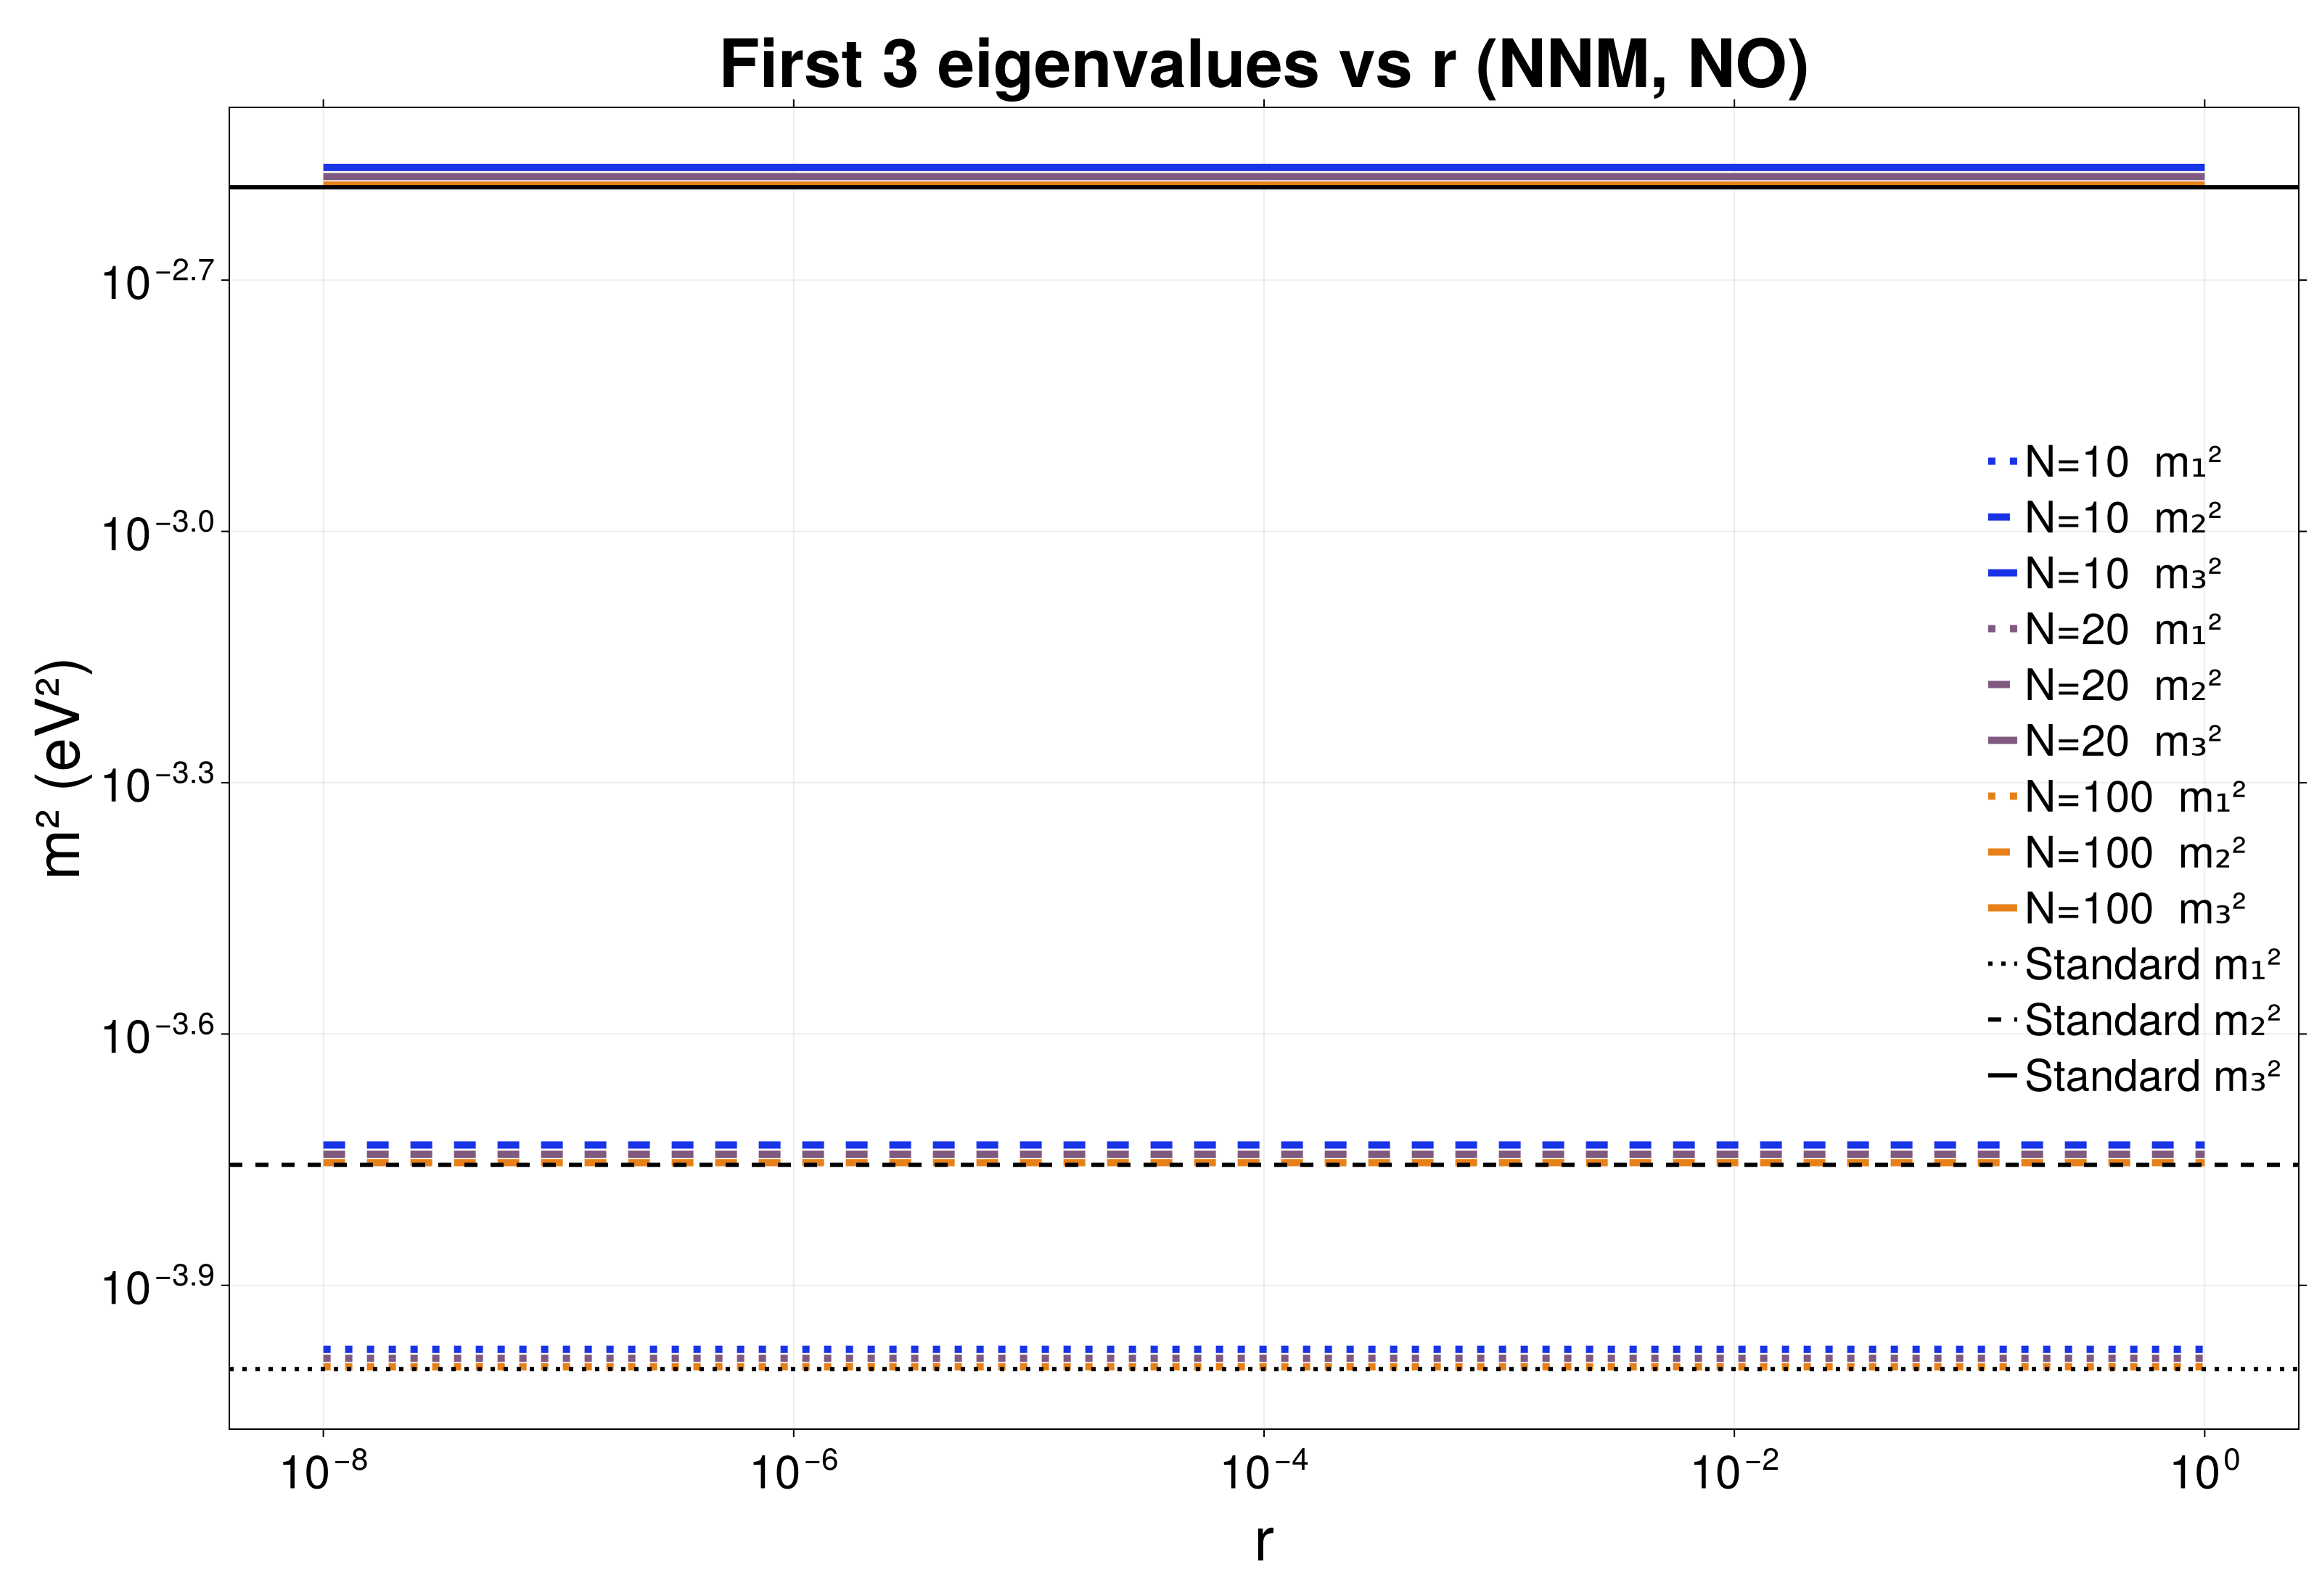

CairoMakie.Screen{IMAGE}


In [73]:
using CairoMakie
using Colors

fig = Figure(
    resolution = (1600, 1100),
    fontsize = 36,
    font = "DejaVu Sans"
)

ax = Axis(
    fig[1, 1],
    xlabel = "r",
    ylabel = "m² (eV²)",
    title = "First 3 eigenvalues vs r (NNM, NO)",
    xscale = log10,
    yscale = log10,

    xlabelsize = 42,
    ylabelsize = 42,
    titlesize = 46,

    xticklabelsize = 32,
    yticklabelsize = 32,

    xgridvisible = true,
    ygridvisible = true,
    xgridstyle = :solid,
    ygridstyle = :solid,
    xgridcolor = RGBAf(0,0,0,0.07),
    ygridcolor = RGBAf(0,0,0,0.07),

    xticksmirrored = true,
    yticksmirrored = true
)

# ---- color gradient ----
start_color = RGB(0.1, 0.2, 0.9)
end_color   = RGB(0.9, 0.5, 0.1)
palette = collect(range(start_color, stop=end_color, length=length(Ns)))

for (i, N) in enumerate(Ns)

    eigvals = results_by_N[N]
    color = palette[i]

    lines!(ax, rs, eigvals[:,1],
        color=color, linewidth=5, linestyle=:dot,
        label="N=$N  m₁²"
    )

    lines!(ax, rs, eigvals[:,2],
        color=color, linewidth=5, linestyle=:dash,
        label="N=$N  m₂²"
    )

    lines!(ax, rs, eigvals[:,3],
        color=color, linewidth=5,
        label="N=$N  m₃²"
    )
end

# ---- Standard values ----
hlines!(ax, (base_params.m₀)^2,
    color=:black, linewidth=3, linestyle=:dot,
    label="Standard m₁²"
)

hlines!(ax, (base_params.m₀)^2 + base_params.Δm²₂₁,
    color=:black, linewidth=3, linestyle=:dash,
    label="Standard m₂²"
)

hlines!(ax, (base_params.m₀)^2 + base_params.Δm²₃₁,
    color=:black, linewidth=3,
    label="Standard m₃²"
)

axislegend(
    ax,
    position=:rc,
    labelsize=30,
    framevisible=false
)

# cleaner paper look
#hidespines!(ax, :top, :right)

save(joinpath(savedir, "eig_vs_r_by_N_first_NNM.png"), fig)

display(fig)

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/scenes.jl:238


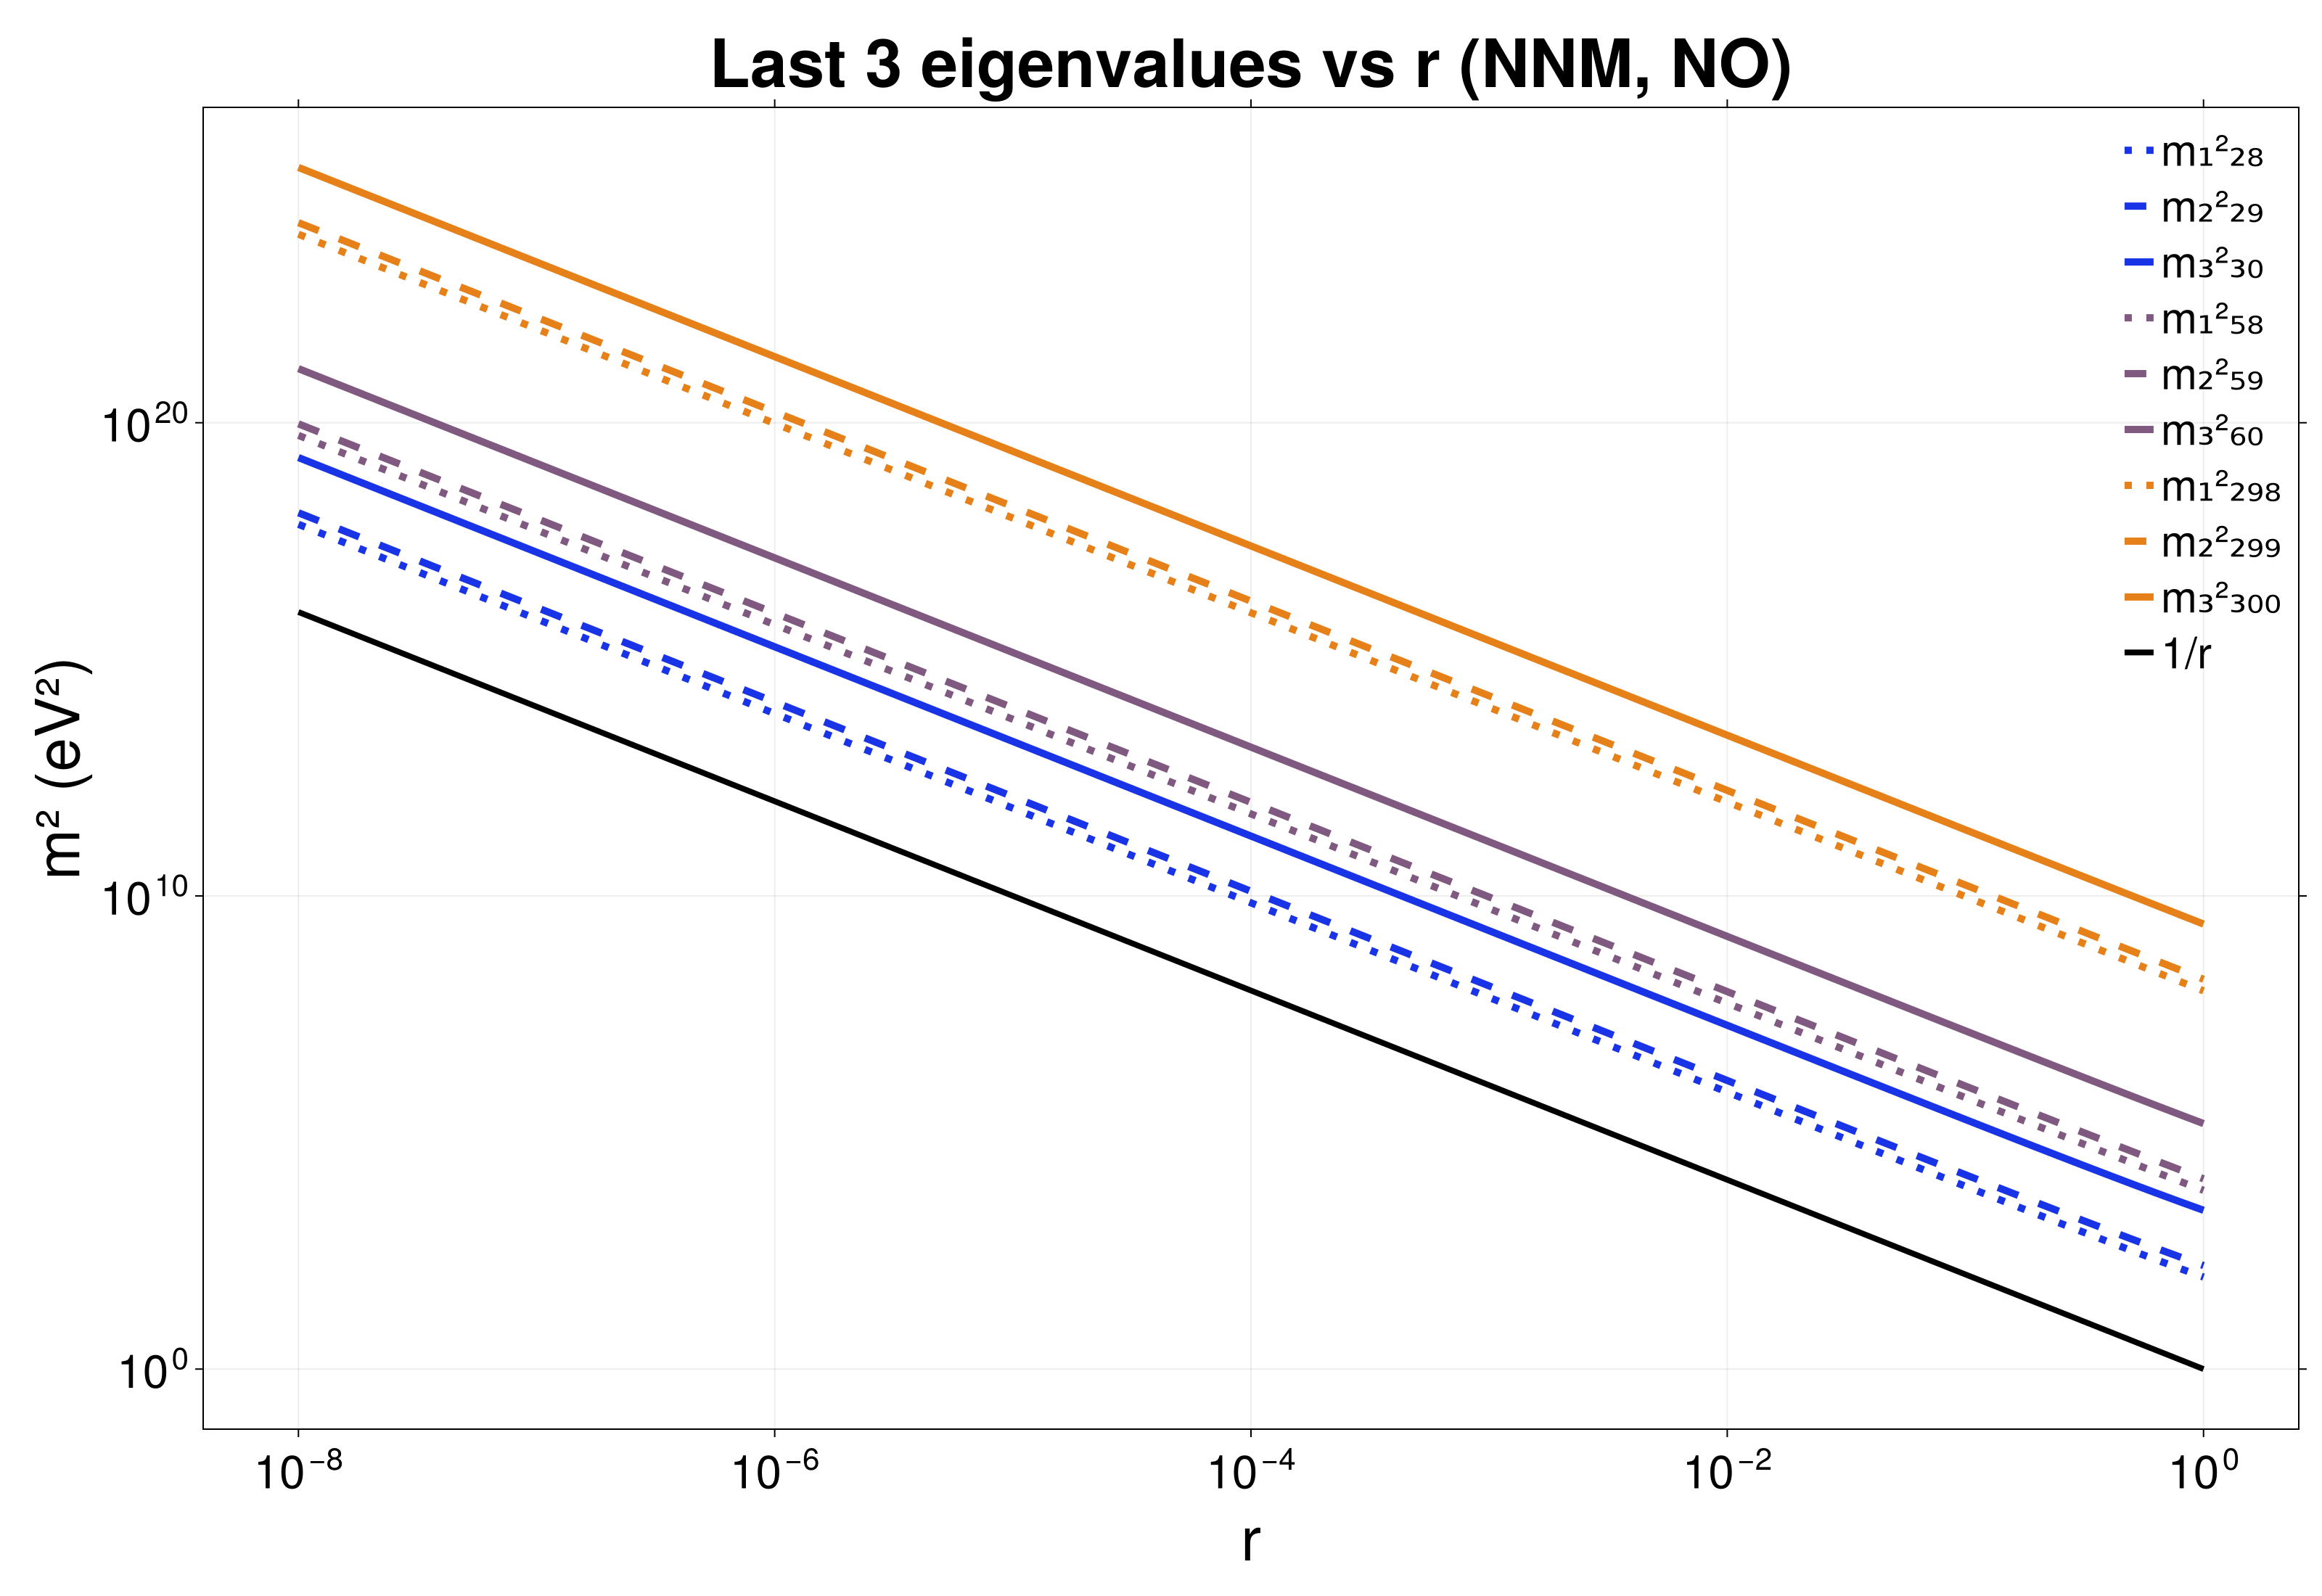

CairoMakie.Screen{IMAGE}


In [74]:
using CairoMakie
using Colors

# ---- Compute results for each N ----
for N in Ns
    eigvals = zeros(length(rs), 3)
    for (i, r) in enumerate(rs)
        params = merge(base_params, (N = float(N), r = r))
        FinalUmatrix, h, eig = matrices_fun(params)

        # store last three eigenvalues
        eigvals[i, 1] = Float64(eig[end-2])
        eigvals[i, 2] = Float64(eig[end-1])
        eigvals[i, 3] = Float64(eig[end])
    end
    results_by_N[N] = eigvals
end

# ---- Figure ----
fig = Figure(resolution=(1600,1100), fontsize=36, font="DejaVu Sans")

ax = Axis(
    fig[1,1],
    xlabel="r",
    ylabel="m² (eV²)",
    title="Last 3 eigenvalues vs r (NNM, NO)",
    xscale=log10,
    yscale=log10,
    xlabelsize=42, ylabelsize=42, titlesize=46,
    xticklabelsize=32, yticklabelsize=32,
    xgridvisible=true, ygridvisible=true,
    xgridstyle=:solid, ygridstyle=:solid,
    xgridcolor=RGBAf(0,0,0,0.07), ygridcolor=RGBAf(0,0,0,0.07),
    xticksmirrored=true, yticksmirrored=true
)

# ---- Color gradient ----
start_color = RGB(0.1,0.2,0.9)
end_color = RGB(0.9,0.5,0.1)
palette = collect(range(start_color, stop=end_color, length=length(Ns)))

# ---- Helper: integer to Unicode subscript ----
digits = collect("₀₁₂₃₄₅₆₇₈₉")  # array of characters
function int_to_subscript(n::Int)
    return join(digits[parse(Int,d)+1] for d in string(n))
end

# ---- Plot all N lines ----
for (idx,N) in enumerate(Ns)
    eigvals = results_by_N[N]
    color = palette[idx]

    # pedices for each eigenvalue (computed integer value)
    ped1 = int_to_subscript(3*N - 2)
    ped2 = int_to_subscript(3*N - 1)
    ped3 = int_to_subscript(3*N - 0)

    # lines with different styles
    lines!(ax, rs, eigvals[:,1], color=color, linewidth=5, linestyle=:dot,  label="m₁²"*ped1)
    lines!(ax, rs, eigvals[:,2], color=color, linewidth=5, linestyle=:dash, label="m₂²"*ped2)
    lines!(ax, rs, eigvals[:,3], color=color, linewidth=5, label="m₃²"*ped3)
end

lines!(
    ax,
    rs,
    rr,
    color = :black,
    linewidth = 4,
    label = "1/r "

)
# ---- Legend & axis clean ----
axislegend(ax, position=:rt, labelsize=30, framevisible=false)


# ---- Save high-res PNG ----
save(joinpath(savedir, "eig_vs_r_by_N_last_NNM.png"), fig)
display(fig)

In [105]:
# Part 2: vary N for several fixed r values
rs = [1e-6, 1e-4, 1e-2, 1]
Ns = LinRange(10, 500,100)  
# N from 10 → 1000 (log-spaced)

savedir = "/home/sofialon/Newtrinos.jl/plots_nnm_s/plots_ready"
isdir(savedir) || mkpath(savedir)

results_by_r = Dict{Float64, Matrix{Float64}}()  # r => (length(Ns) x 3) matrix for h1,h2,h3

for r in rs
    eigvals = zeros(length(Ns), 3)

    for (i, N) in enumerate(Ns)
        params = merge(base_params, (N = float(N), r = r))

        # call matrices_fun and extract h robustly
        F, h, eig= matrices_fun(params)
     
        # store first three entries
        eigvals[i, 1] = Float64(eig[1])
        eigvals[i, 2] = Float64(eig[2])
        eigvals[i, 3] = Float64(eig[3])
    end

    results_by_r[r] = eigvals
end

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/scenes.jl:238


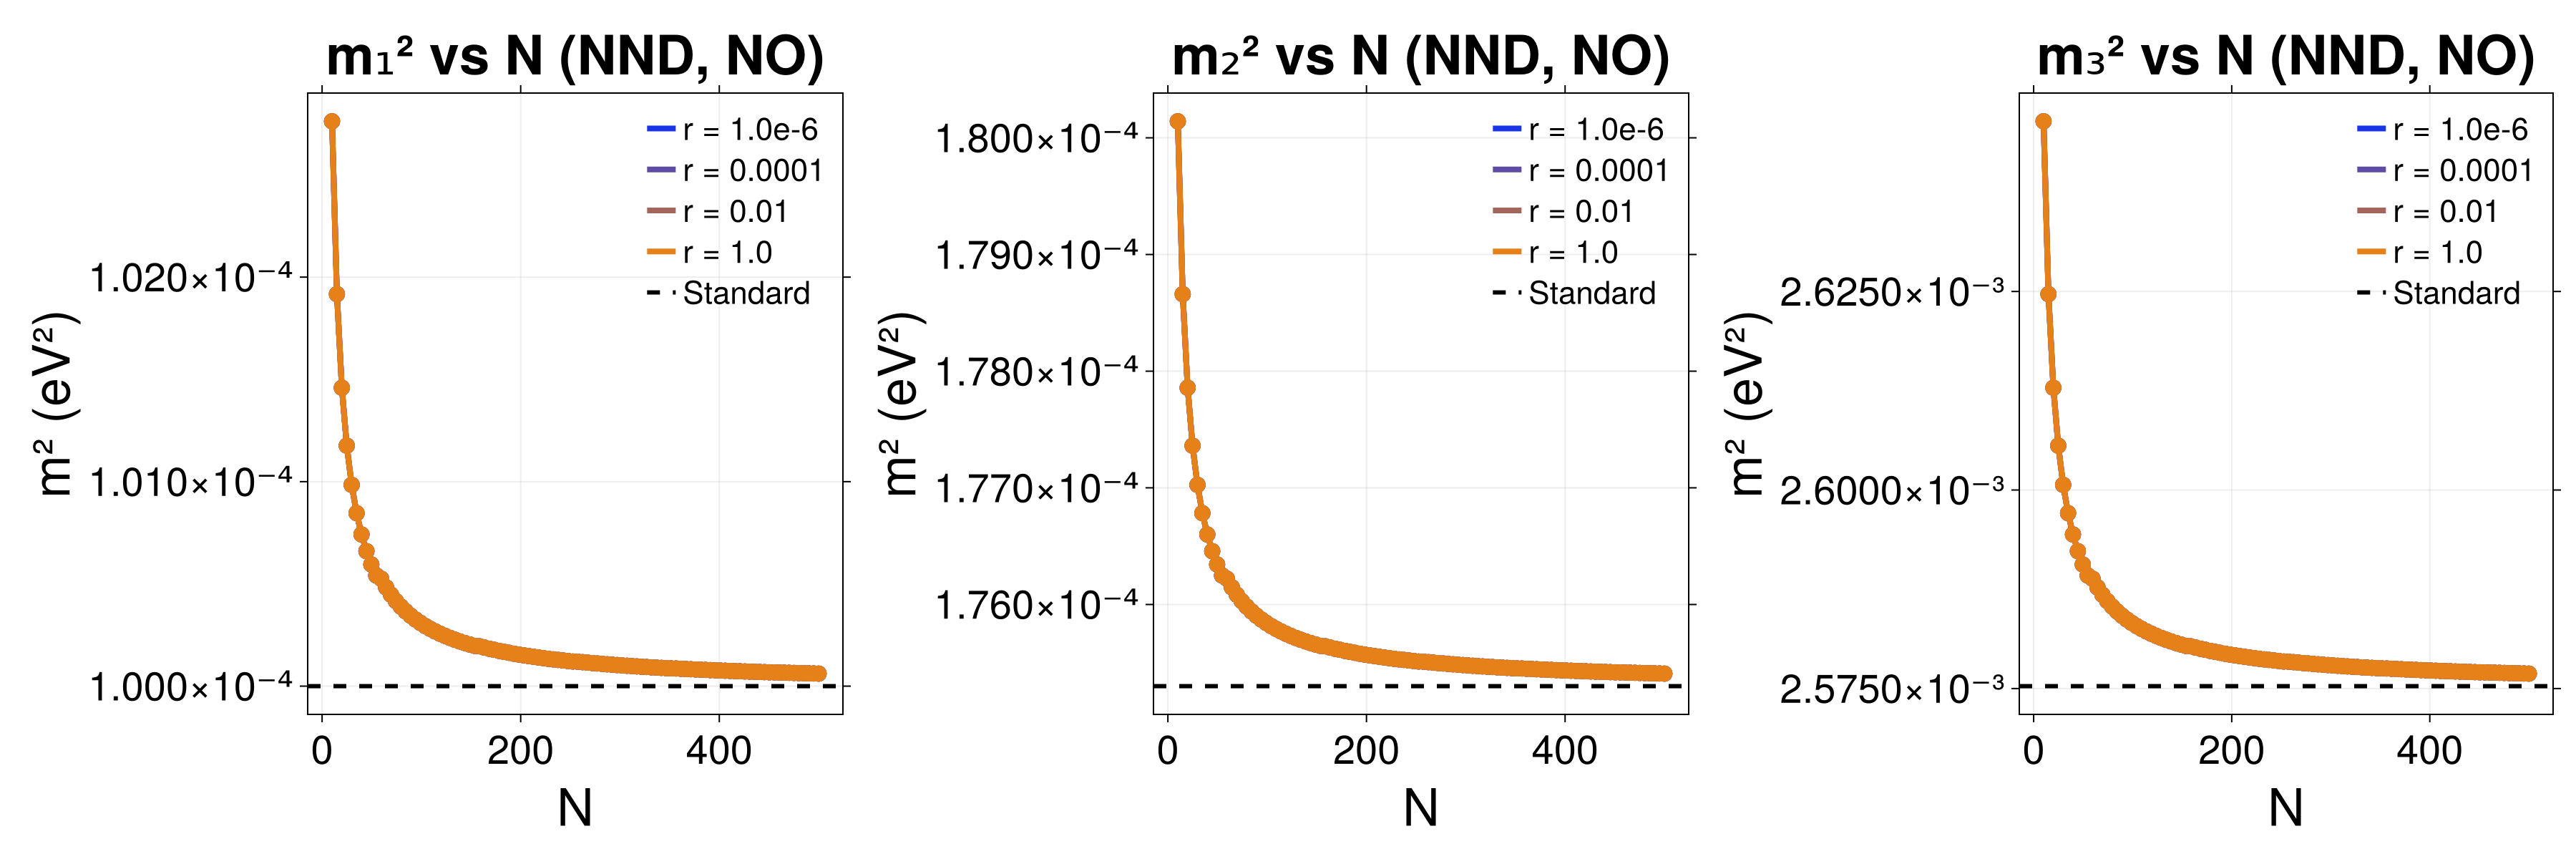

CairoMakie.Screen{IMAGE}


In [106]:
using CairoMakie
using Colors

# ---- Create figure ----
fig2 = Figure(resolution=(1800, 600), fontsize=36, font="DejaVu Sans")

# ---- Strong visible gradient for r values ----
start_color = RGB(0.1, 0.2, 0.9)   # deep blue
end_color   = RGB(0.9, 0.5, 0.1)   # strong orange
palette = collect(range(start_color, stop=end_color, length=length(rs)))

# Standard values for horizontal lines
val = [base_params.m₀^2, base_params.m₀^2 + base_params.Δm²₂₁, base_params.m₀^2 + base_params.Δm²₃₁]

# Unicode names for eigenvalues
stringname = ["m₁²", "m₂²", "m₃²"]

for j in 1:3

    ax = Axis(
        fig2[1, j],
        xlabel = "N",
        ylabel = "m² (eV²)",
        title = stringname[j]*" vs N (NND, NO)",
        xlabelsize = 36,
        ylabelsize = 36,
        titlesize = 38,
        xticklabelsize = 28,
        yticklabelsize = 28,
        xgridvisible = true,
        ygridvisible = true,
        xgridcolor = :gray90,
        ygridcolor = :gray90,
        xticksmirrored = true,
        yticksmirrored = true
    )

    for (ir, r) in enumerate(rs)
        eigvals = results_by_r[r]
        color = palette[ir]

        # Line
        lines!(ax, Ns, eigvals[:, j], color=color, linewidth=4, label="r = $(r)")

        # Scatter points
        scatter!(ax, Ns, eigvals[:, j], color=color, marker=:circle, markersize=16)
    end

    

    # Horizontal standard line
    hlines!(ax, val[j], color=:black, linewidth=3, linestyle=:dash, label="Standard")

    # Subtle grid
    ax.xgridstyle = :solid
    ax.ygridstyle = :solid
    ax.xgridcolor = RGBAf(0,0,0,0.07)
    ax.ygridcolor = RGBAf(0,0,0,0.07)

    # Legend
    axislegend(ax, position=:rt, labelsize=22, framevisible=false)
end

# ---- Save high-resolution PNG ----
save(joinpath(savedir, "eig_vs_N_by_r_first_NND.png"), fig2)

display(fig2)

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/scenes.jl:238


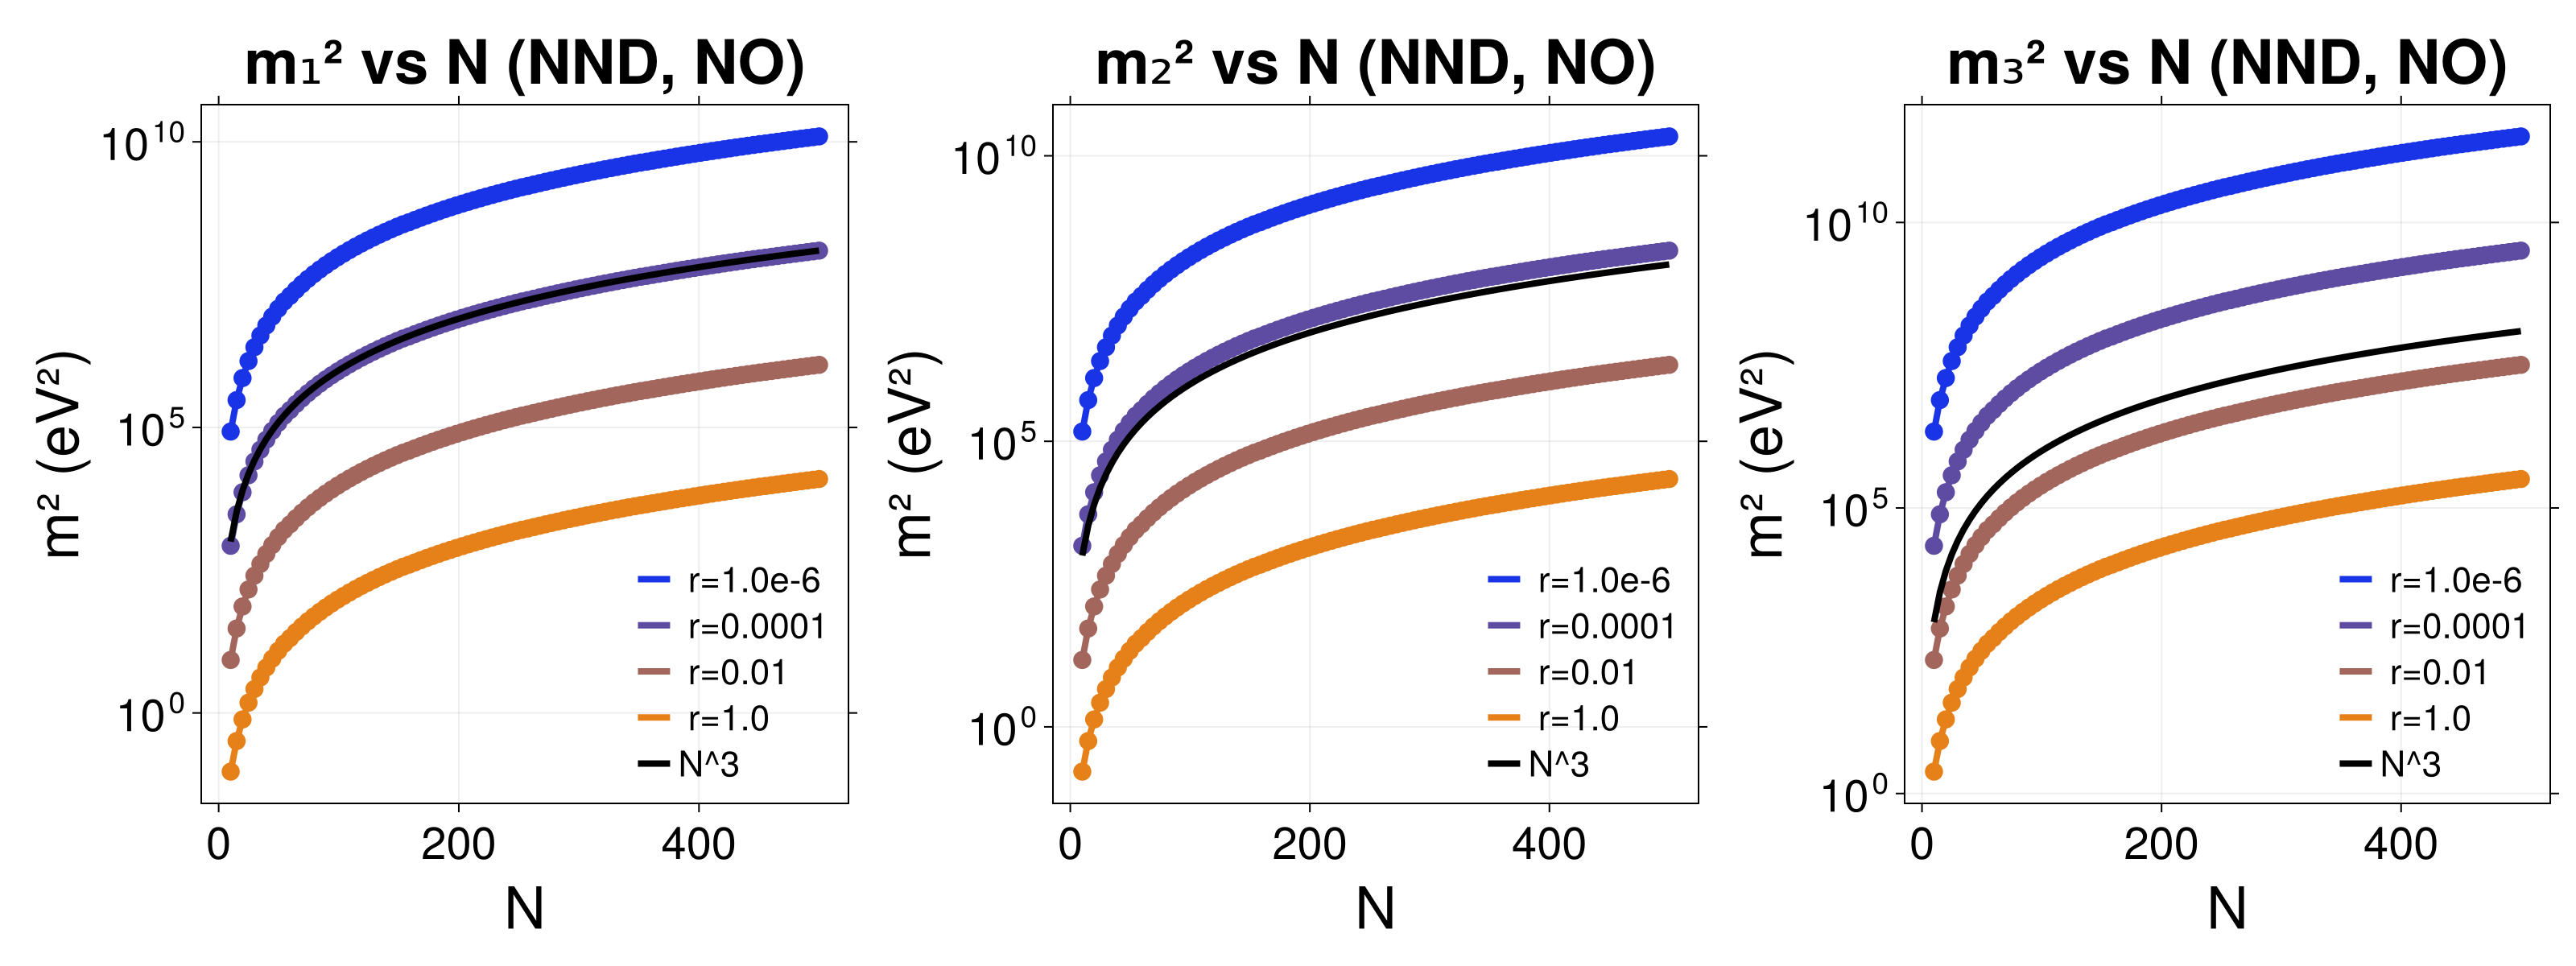

CairoMakie.Screen{IMAGE}


In [107]:
using CairoMakie
using Colors

NN= (Ns).^3 # N from 10 → 1000 (log-spaced)

for r in rs
    eigvals = zeros(length(Ns), 3)

    for (i, N) in enumerate(Ns)
        params = merge(base_params, (N = float(N), r = r))

        # call matrices_fun and extract h robustly
        F, h, eig= matrices_fun(params)
     
        # store first three entries
        eigvals[i, 1] = Float64(eig[end-2])
        eigvals[i, 2] = Float64(eig[end-1])
        eigvals[i, 3] = Float64(eig[end])
    end

    results_by_r[r] = eigvals
end

# ---- Create figure ----
fig2 = Figure(resolution=(1600, 600), fontsize=36, font="DejaVu Sans")

# ---- Strong visible gradient for r values ----
start_color = RGB(0.1, 0.2, 0.9)
end_color   = RGB(0.9, 0.5, 0.1)
palette = collect(range(start_color, stop=end_color, length=length(rs)))

# ---- Eigenvalue base names ----
base_names = ["m₁²", "m₂²", "m₃²"]

# ---- Helper: integer to Unicode subscript ----
digits = collect("₀₁₂₃₄₅₆₇₈₉")
function int_to_subscript(n::Int)
    return join(digits[parse(Int,d)+1] for d in string(n))
end

# ---- Plot each eigenvalue panel ----
for j in 1:3
    ax = Axis(
        fig2[1, j],
        xlabel = "N",
        ylabel = "m² (eV²)",
        title = base_names[j]*" vs N (NND, NO)",
        yscale = log10,
        xlabelsize = 36,
        ylabelsize = 36,
        titlesize = 38,
        xticklabelsize = 28,
        yticklabelsize = 28,
        xgridvisible = true,
        ygridvisible = true,
        xgridcolor = :gray90,
        ygridcolor = :gray90,
        xticksmirrored = true,
        yticksmirrored = true
    )

    for (ir, r) in enumerate(rs)
        eigvals = results_by_r[r]
        color = palette[ir]

        # ---- Compute pedex number for legend ----
        # Use first N as representative, but cast to Int
        N_val = Int(Ns[1])
        pedex_number = 3*N_val - (3-j)
        pedex = int_to_subscript(pedex_number)

        legend_label =  " r=$(r)"

        # Line and scatter
        lines!(ax, Ns, eigvals[:, j], color=color, linewidth=4, label=legend_label)
        scatter!(ax, Ns, eigvals[:, j], color=color, marker=:circle, markersize=16)
    end
    lines!(
    ax,
    Ns,
    NN,
    color = :black,
    linewidth = 4,
    label = "N^3" 

     )

    # subtle grid
    ax.xgridstyle = :solid
    ax.ygridstyle = :solid
    ax.xgridcolor = RGBAf(0,0,0,0.07)
    ax.ygridcolor = RGBAf(0,0,0,0.07)

    # Legend
    axislegend(ax, position=:rb, labelsize=22, framevisible=false)
end

# ---- Save PNG ----
save(joinpath(savedir, "eig_vs_N_by_r_high_NND.png"), fig2)
display(fig2)

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/scenes.jl:238


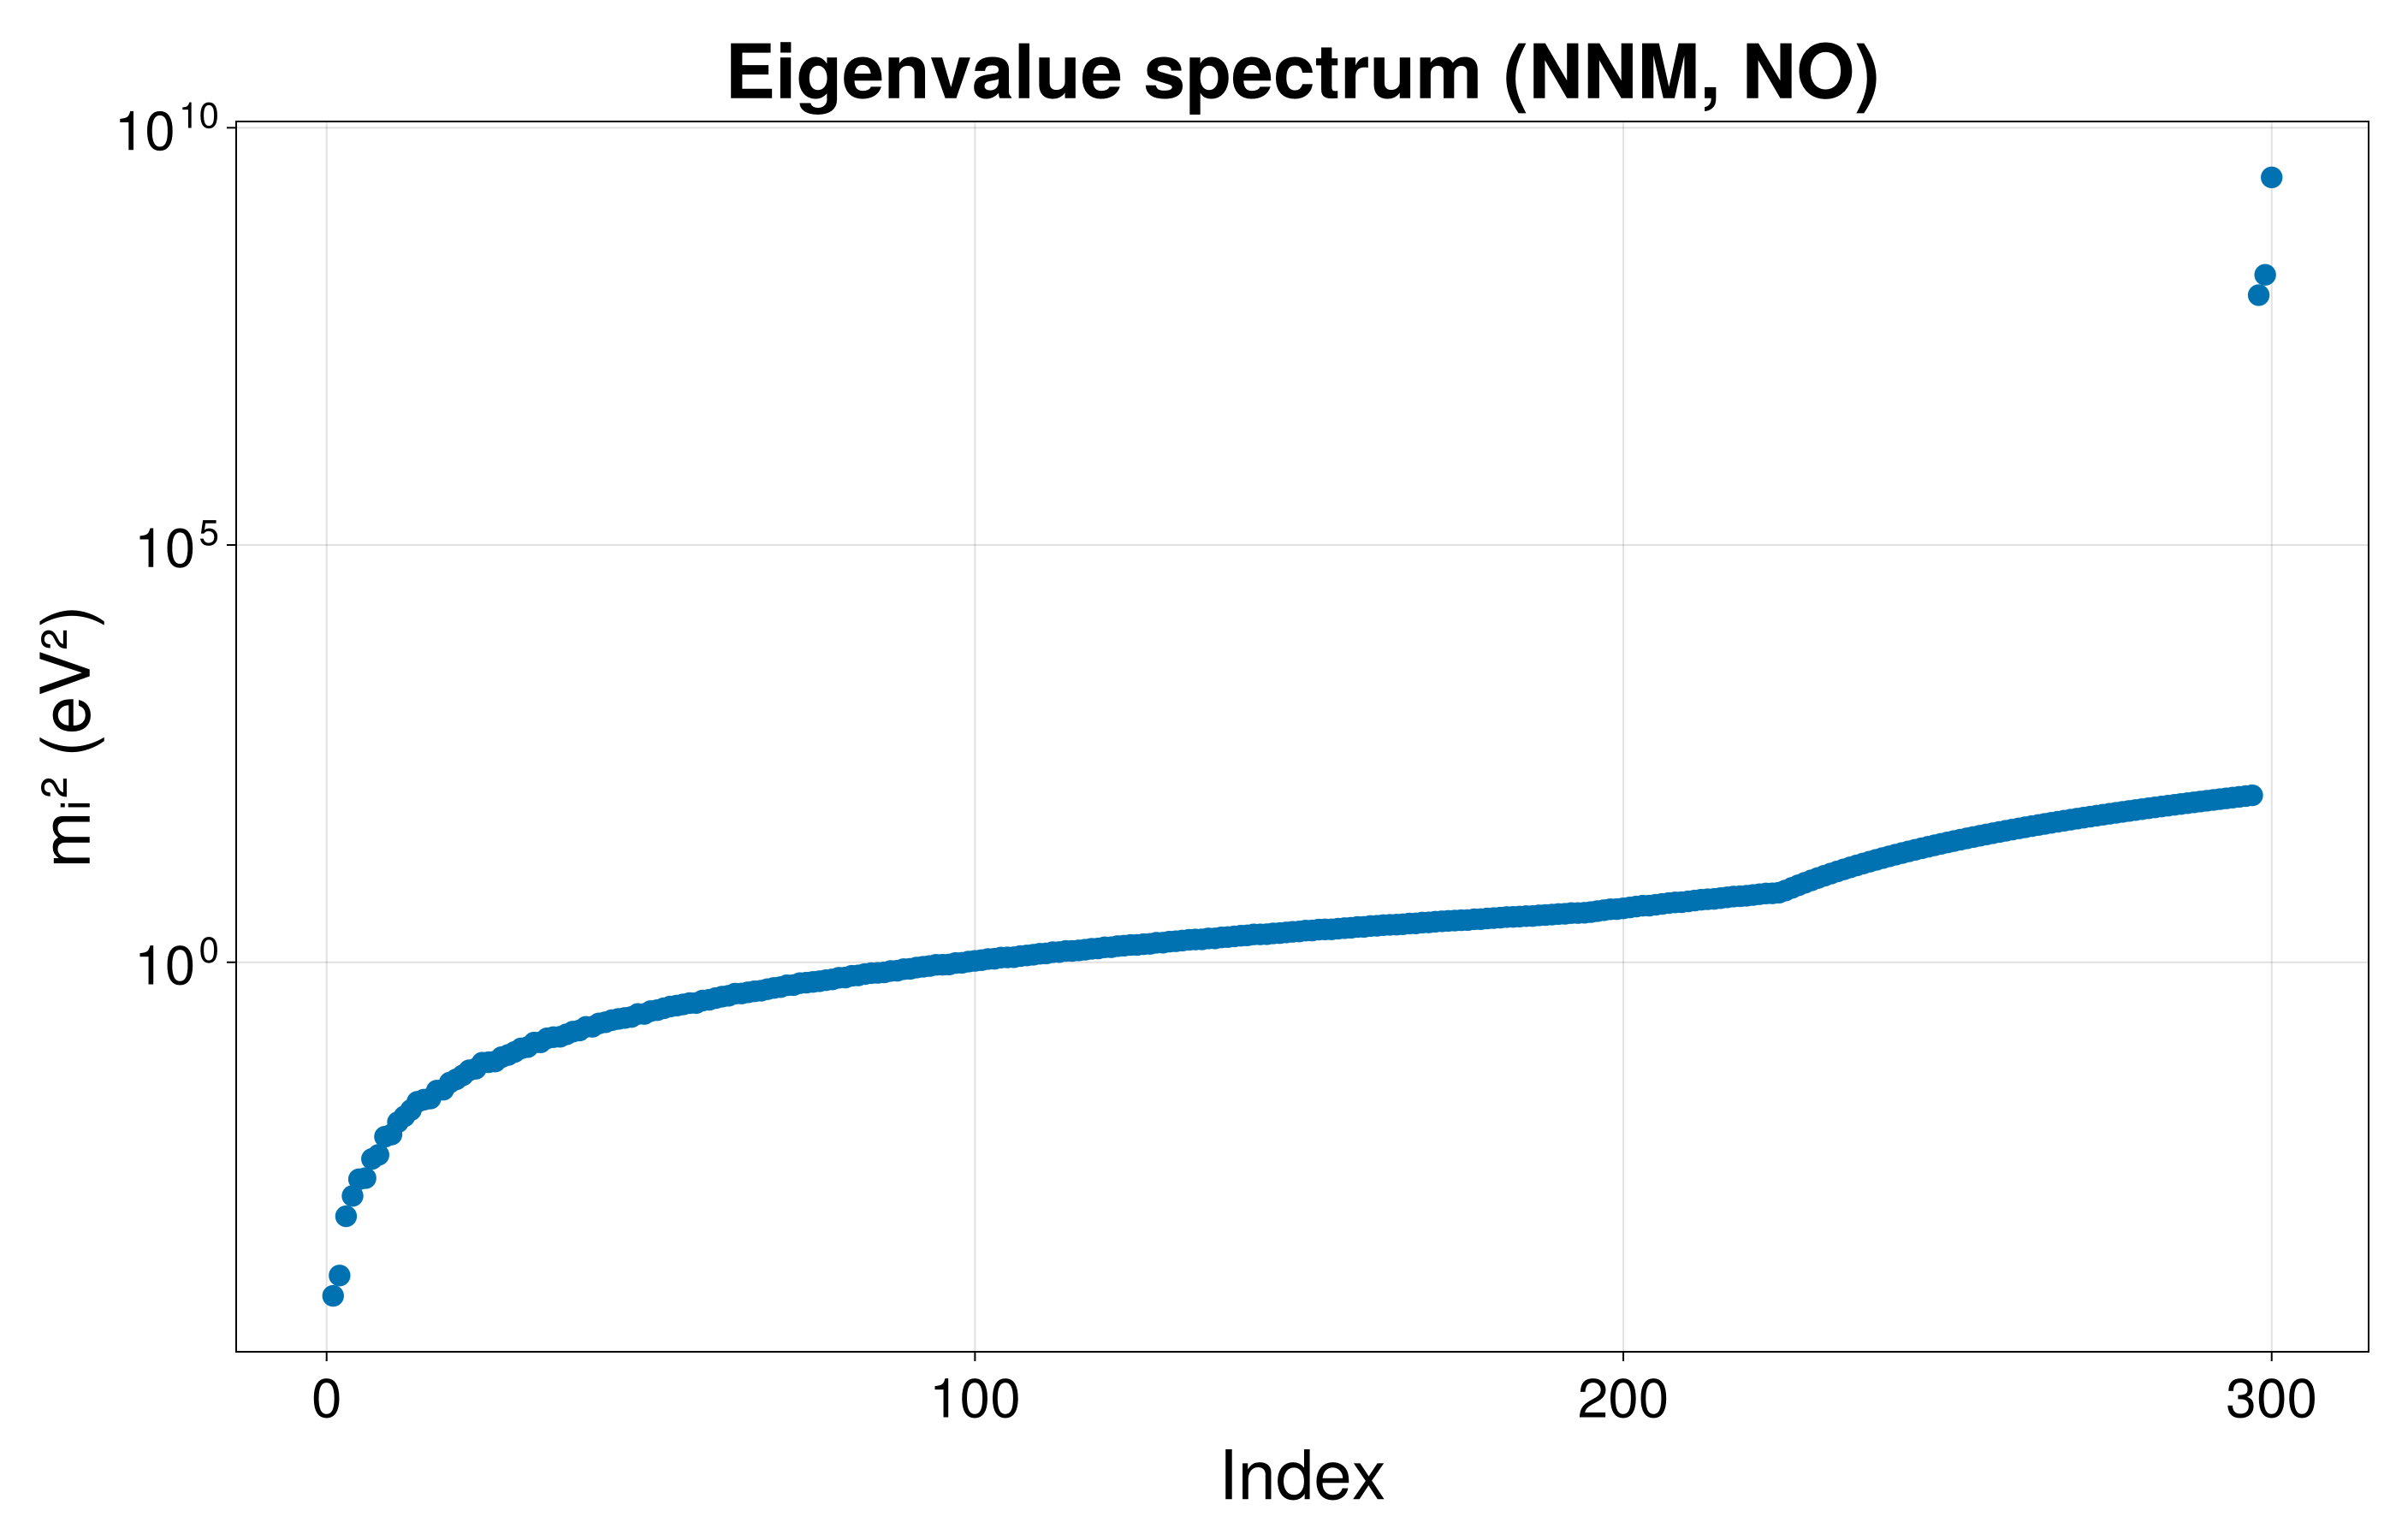

CairoMakie.Screen{IMAGE}


In [21]:
using CairoMakie


# Example: compute eigenvalues once
params = merge(base_params, (N = 100, r = 1))
FinalUmatrix, h, eigenvalues = matrices_fun(params)

vals = sort(eigenvalues)
idx = 1:length(vals)

fig = Figure(
    resolution = (1400, 900),
    fontsize = 34,
    font = "DejaVu Sans"
)

ax = Axis(
    fig[1,1],
    xlabel = "Index",
    ylabel = "mᵢ² (eV²)",
    title = "Eigenvalue spectrum (NNM, NO)",
    yscale = log10,
    xlabelsize = 40,
    ylabelsize = 40,
    titlesize = 44,
    xticklabelsize = 32,
    yticklabelsize = 32,
    xgridvisible = true,
    ygridvisible = true
)

scatter!(
    ax,
    idx,
    vals,
    markersize = 18
)

save(joinpath(savedir, "eigenvalue_spectrum_NNM_NO.png"), fig)

display(fig)

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/scenes.jl:238


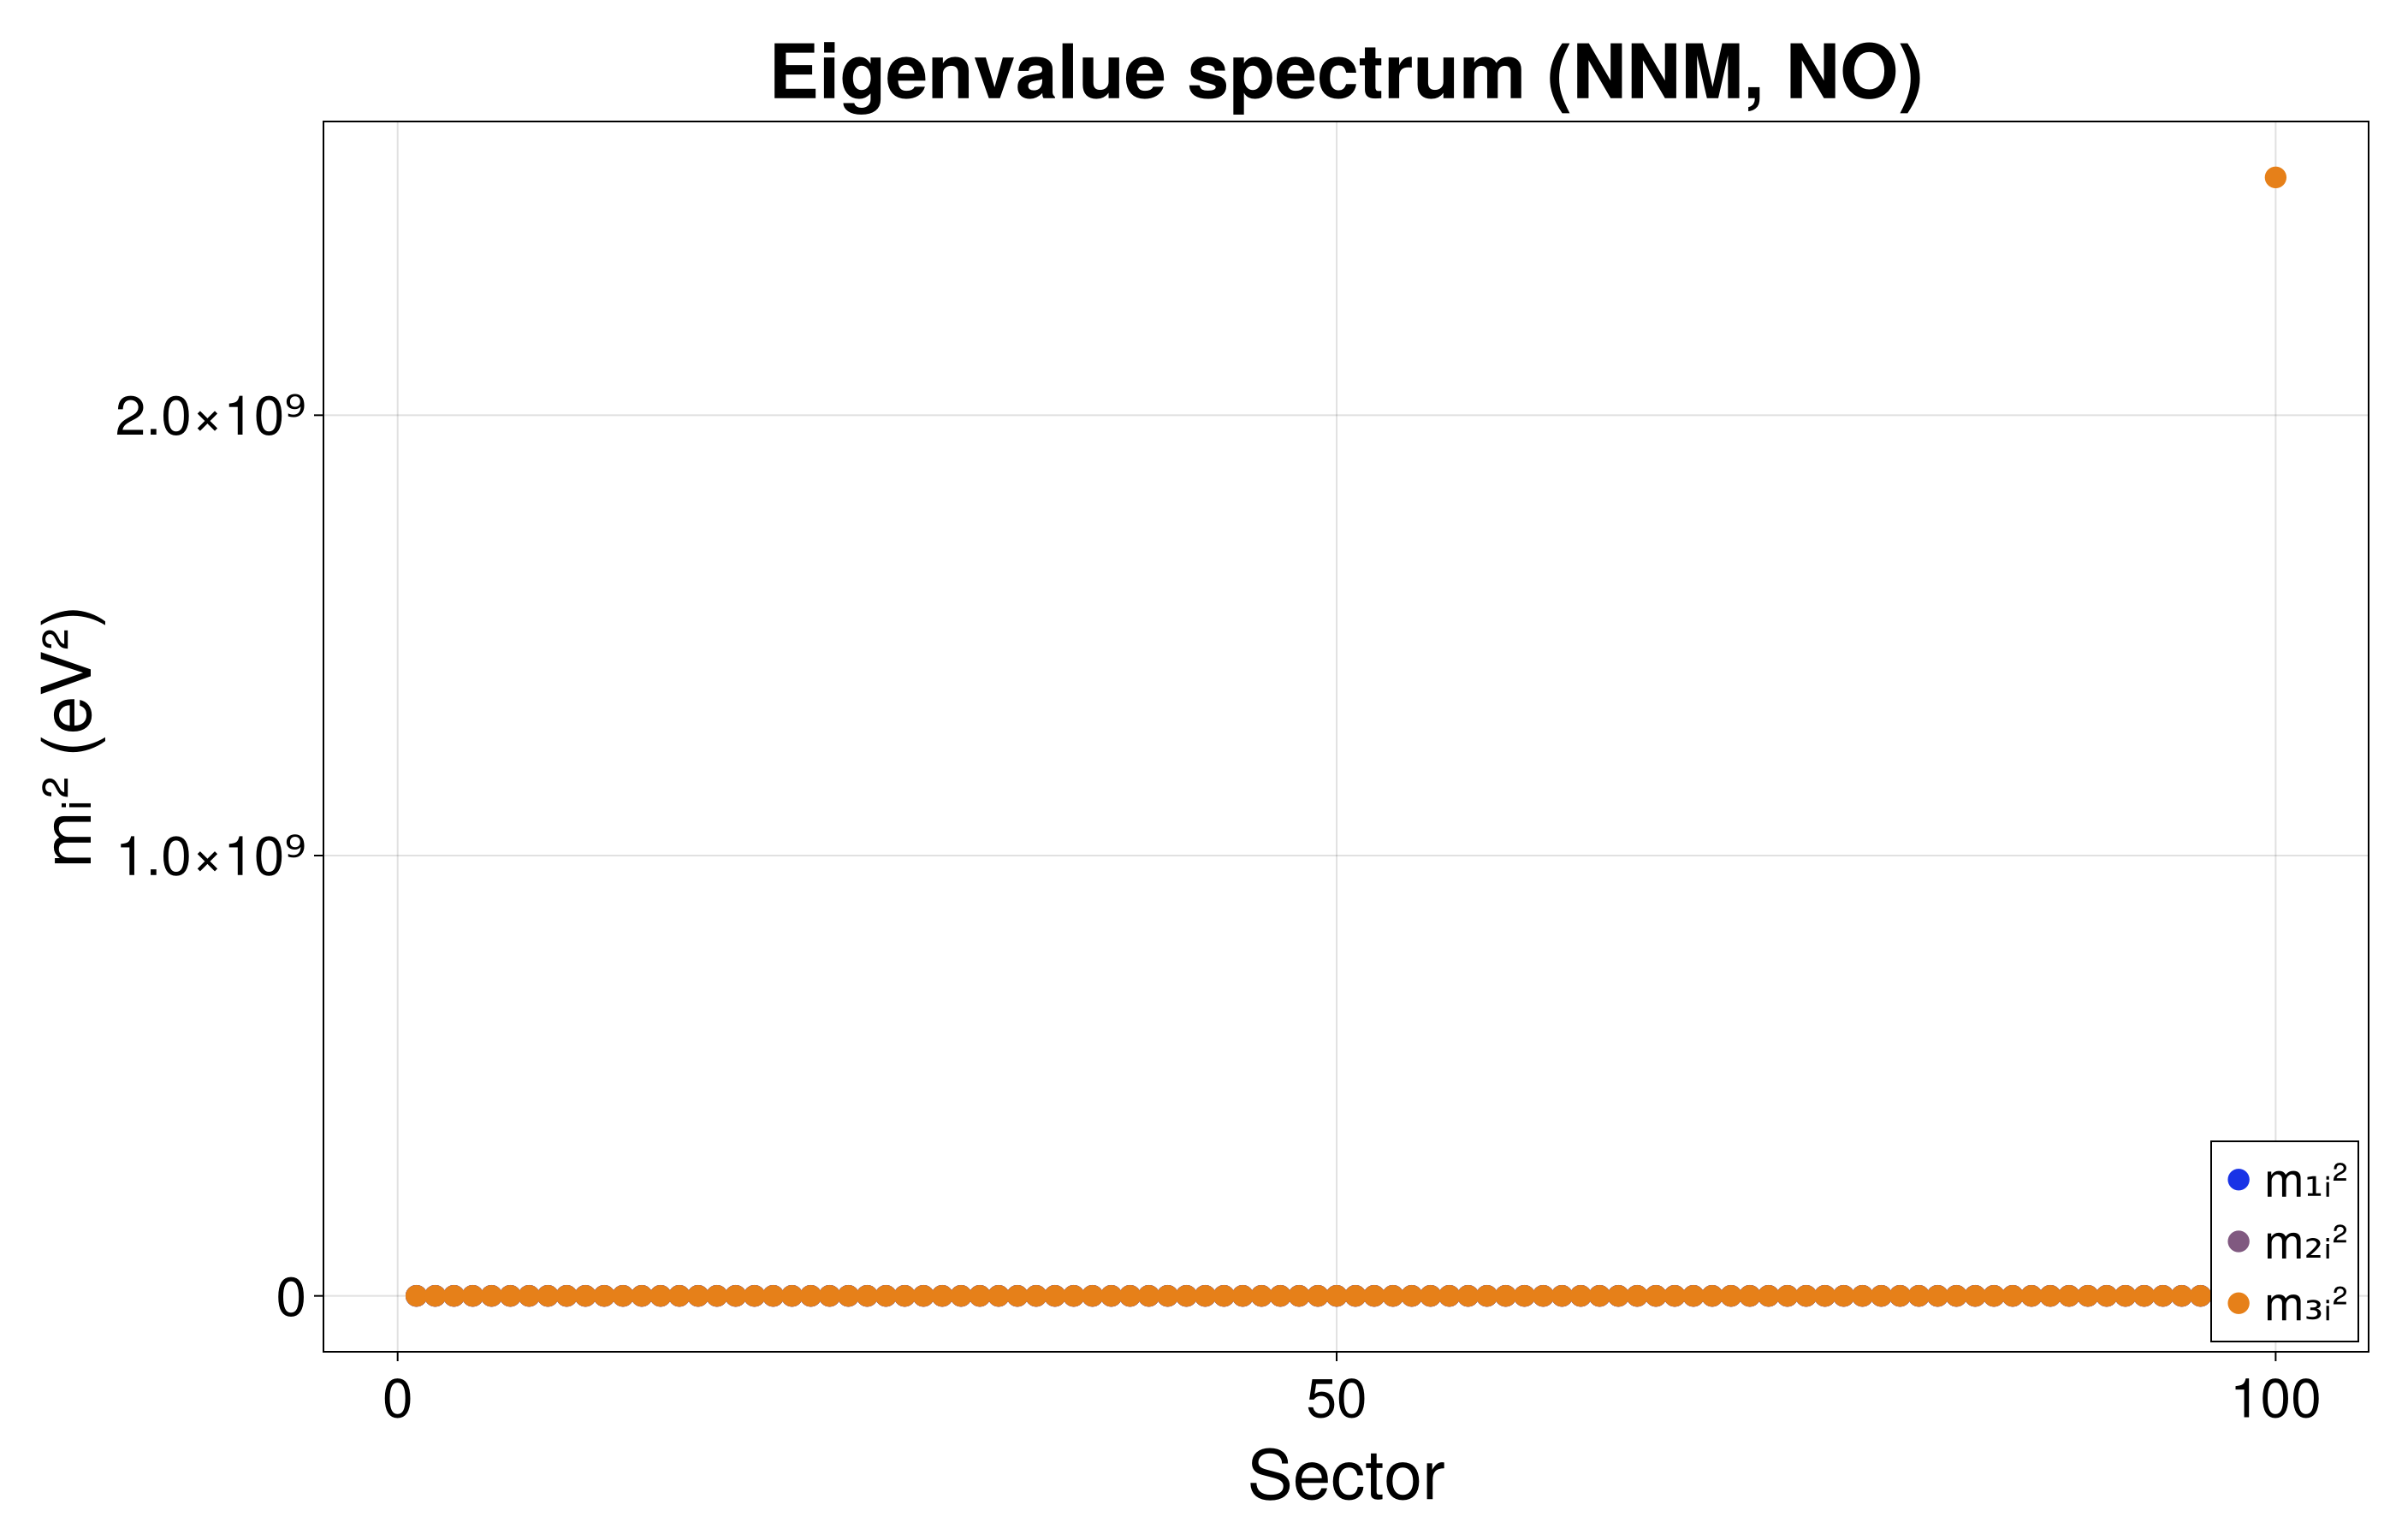

CairoMakie.Screen{IMAGE}


In [24]:
using CairoMakie
using Colors

# compute eigenvalues
params = merge(base_params, (N =100, r = 1))
FinalUmatrix, h, eigenvalues = matrices_fun(params)

idx = 1:length(eigenvalues)

# groups
idx0 = idx[1:100] 
idx1=idx[1:3:end]  # 3k-2
idx2 = idx[2:3:end]   # 3k-1
idx3 = idx[3:3:end]   # 3k

# sort values once if desired (optional)
# eigenvalues = sort(eigenvalues)

# ---- gradient palette ----
start_color = RGB(0.1, 0.2, 0.9)
end_color   = RGB(0.9, 0.5, 0.1)
palette = collect(range(start_color, stop=end_color, length=3))

fig = Figure(
    resolution = (1400, 900),
    fontsize = 34,
    font = "DejaVu Sans"
)

ax = Axis(
    fig[1,1],
    xlabel = "Sector",
    ylabel = "mᵢ² (eV²)",
    title = "Eigenvalue spectrum (NNM, NO)",
    #yscale = log10,
    xlabelsize = 40,
    ylabelsize = 40,
    titlesize = 44,
    xticklabelsize = 32,
    yticklabelsize = 32,
    xgridvisible = true,
    ygridvisible = true
)

scatter!(
    ax,
    idx0,
    eigenvalues[idx1],
    color = palette[1],
    markersize = 18,
    label = "m₁ᵢ²"
)

scatter!(
    ax,
    idx0,
    eigenvalues[idx2],
    color = palette[2],
    markersize = 18,
    label = "m₂ᵢ²"
)

scatter!(
    ax,
    idx0,
    eigenvalues[idx3],
    color = palette[3],
    markersize = 18,
    label = "m₃ᵢ²"
)

axislegend(ax, position = :rb, labelsize = 28)

#save(joinpath(savedir, "eigenvalue_spectrum_groups_nnm_no.png"), fig)

display(fig)

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/scenes.jl:238


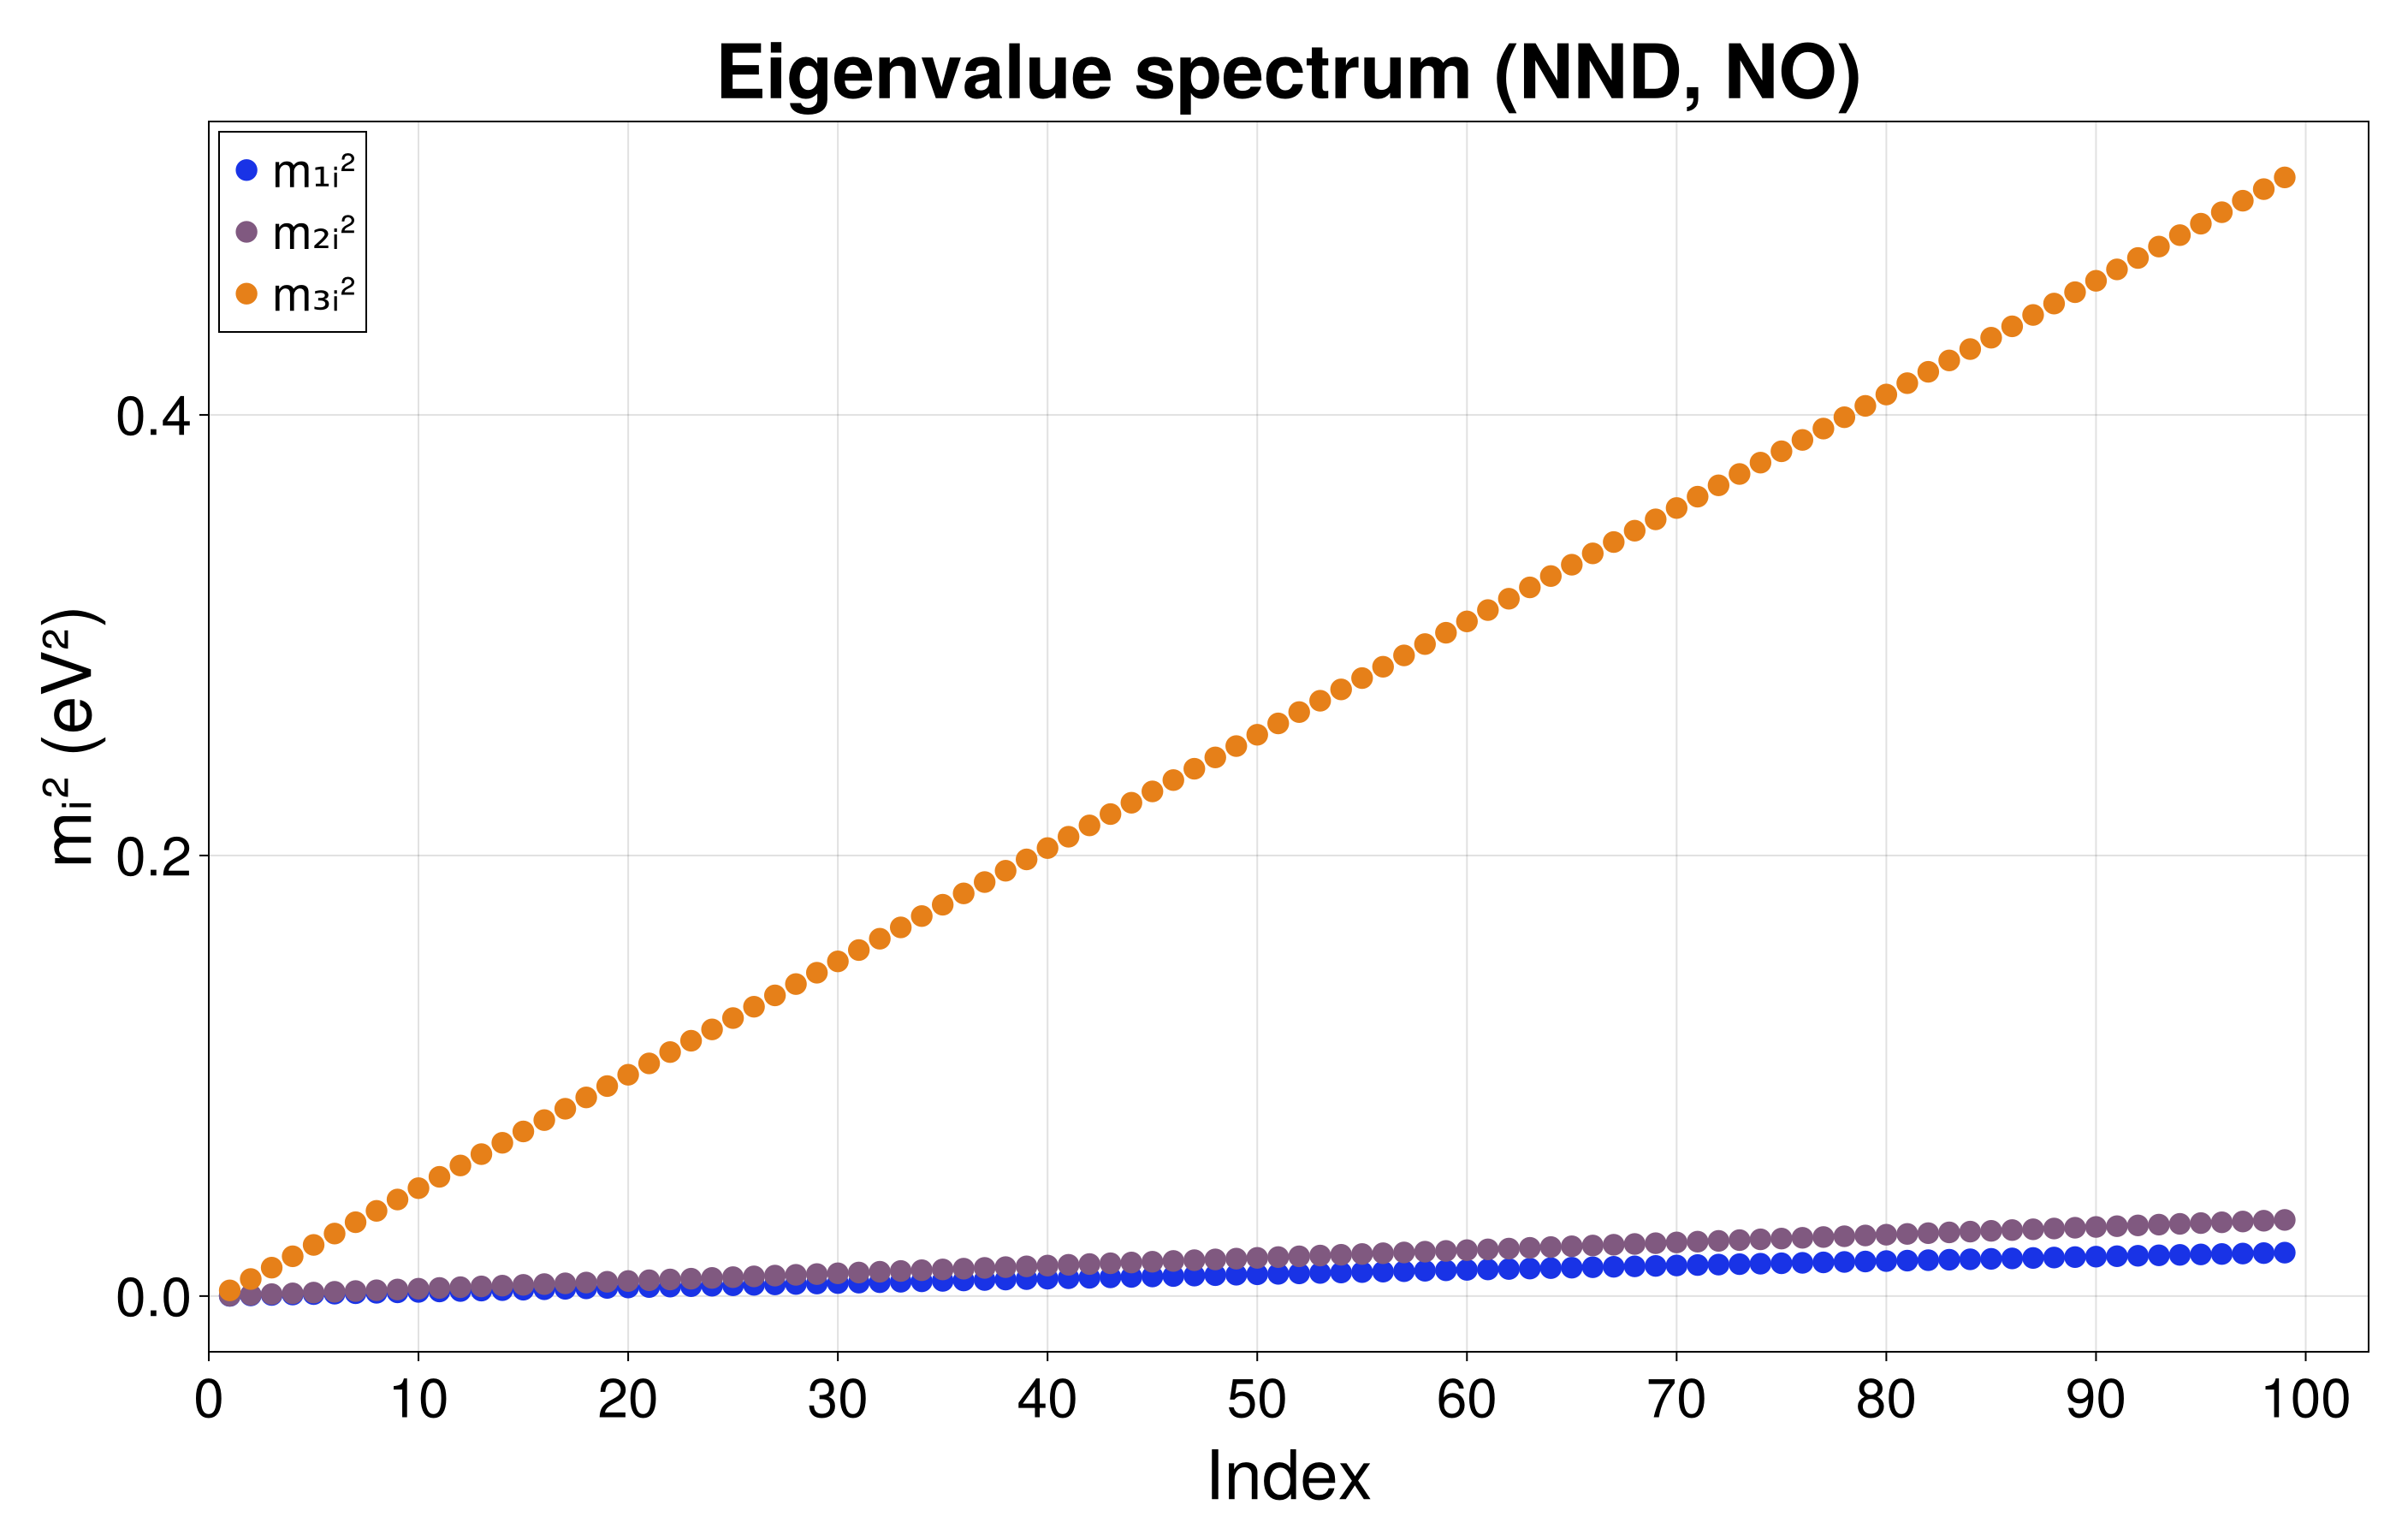

In [39]:
using CairoMakie
using Colors

# compute eigenvalues
params = merge(base_params, (N = 100, r = 1))
FinalUmatrix, h, eigenvalues = matrices_fun(params)

# remove the last three eigenvalues
eigenvalues = eigenvalues[1:end-3]

# indices
idx = 1:length(eigenvalues)
idx0 = idx[1:99] 
idx1=idx[1:3:end]  # 3k-2
idx2 = idx[2:3:end]   # 3k-1
idx3 = idx[3:3:end] 

# ---- gradient palette ----
start_color = RGB(0.1, 0.2, 0.9)
end_color   = RGB(0.9, 0.5, 0.1)
palette = collect(range(start_color, stop=end_color, length=3))

fig = Figure(
    resolution = (1400, 900),
    fontsize = 34,
    font = "DejaVu Sans"
)

ax = Axis(
    fig[1,1],
    xlabel = "Index",
    ylabel = "mᵢ² (eV²)",
    title = "Eigenvalue spectrum (NND, NO)",
    xlabelsize = 40,
    ylabelsize = 40,
    titlesize = 44,
    xticklabelsize = 32,
    yticklabelsize = 32,
    xgridvisible = true,
    ygridvisible = true
)

# x-axis limits
xlims!(ax, 0, 103)
ax.xticks = 0:10:100

scatter!(
    ax,
    idx0,
    eigenvalues[idx1],
    color = palette[1],
    markersize = 18,
    label = "m₁ᵢ²"
)

scatter!(
    ax,
    idx0,
    eigenvalues[idx2],
    color = palette[2],
    markersize = 18,
    label = "m₂ᵢ²"
)

scatter!(
    ax,
    idx0,
    eigenvalues[idx3],
    color = palette[3],
    markersize = 18,
    label = "m₃ᵢ²"
)

axislegend(ax, position = :lt, labelsize = 28)

display(fig)

# optional save
 save(joinpath(savedir, "eigenvalue_spectrum_groups_nnd_no_scale_i.png"), fig)